# NinaPro DB1 — Full-Dataset EDA
## All 27 Subjects × All 3 Exercises + Downstream 8-Subject/3-Movement Subset

This notebook performs **exploratory data analysis on the complete preprocessed NinaPro DB1 dataset**, rather than only Exercise 1.

## Full EDA scope

```text
Dataset:       NinaPro DB1
Subjects:      27
Exercises:     1, 2, 3
Expected MAT:  27 × 3 = 81 files
EMG:           10 channels
Glove:         22 channels
Sampling:      100 Hz in the preprocessed DB1 files
Labels:        restimulus
Repetitions:   rerepetition
```

The full-dataset EDA includes:

- file and signal inventory;
- shape/alignment checks;
- missing/infinite-value checks;
- total samples and recording duration;
- exercise coverage;
- subject coverage;
- active/rest sample counts;
- movement-label distribution across the whole dataset;
- repetition coverage;
- EMG descriptive statistics;
- glove descriptive statistics;
- representative signal distributions;
- rest-vs-movement EMG comparison;
- between-subject variability;
- between-exercise variability;
- EMG-channel correlation;
- EMG–glove relationship;
- temporal signal examples;
- PCA visualization of sampled EMG activity.

---

# Downstream experimental subset

The later wrist-angle regression experiment does **not** use the whole DB1 dataset.

It uses:

```text
Subjects:       1–8
Exercise:       2
Movements:
    13 = WF    (wrist flexion)
    16 = WUD   (wrist ulnar deviation)
    17 = WECH  (wrist extension + closed hand)

Target glove sensor:
    zero-based column 20
    = GLOVE_21 in one-based display notation
```

The notebook therefore ends with a **separate focused EDA section** for this selected subset.

This separation is important:

> Full DB1 is used for dataset understanding and EDA; the later model is intentionally trained/evaluated only on the selected 8 subjects and 3 wrist movements.

## 1. Imports and configuration

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import re
import shutil
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from IPython.display import display
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.width",
    180,
)

RANDOM_STATE = 42
FS = 100

N_SUBJECTS = 27
EXERCISES = (1, 2, 3)

N_EMG = 10
N_GLOVE = 22

# Balanced sample used only for descriptive EDA.
# Exact counts/quality checks still use all files.
EDA_ROWS_PER_FILE = 1500

# Large plots use a further cap for speed.
PLOT_SAMPLE_MAX = 60_000
PCA_SAMPLE_MAX = 40_000
CORRELATION_SAMPLE_MAX = 50_000

# Downstream model subset used later in the project.
SELECTED_SUBJECTS = tuple(
    range(1, 9)
)

SELECTED_EXERCISE = 2

SELECTED_MOVEMENTS = {
    13: "WF",
    16: "WUD",
    17: "WECH",
}

TARGET_GLOVE_COLUMN = 20  # zero-based = GLOVE_21

BASE_URL = (
    "https://ninapro.hevs.ch/files/"
    "DB1/Preprocessed"
)

ON_KAGGLE = Path(
    "/kaggle"
).exists()

WORK_DIR = (
    Path(
        "/kaggle/working/"
        "ninapro_db1_full_eda"
    )
    if ON_KAGGLE
    else Path(
        "./ninapro_db1_full_eda"
    )
)

ZIP_DIR = (
    WORK_DIR
    / "zip_files"
)

MAT_DIR = (
    WORK_DIR
    / "mat_files"
)

OUTPUT_DIR = (
    WORK_DIR
    / "eda_outputs"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)

for directory in [
    ZIP_DIR,
    MAT_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

rng = np.random.default_rng(
    RANDOM_STATE
)

print(
    "Working directory:",
    WORK_DIR.resolve(),
)

print(
    "EDA output directory:",
    OUTPUT_DIR.resolve(),
)

print(
    "Expected full DB1 files:",
    N_SUBJECTS
    * len(EXERCISES),
)

Working directory: /kaggle/working/ninapro_db1_full_eda
EDA output directory: /kaggle/working/ninapro_db1_full_eda/eda_outputs
Expected full DB1 files: 81


## 2. Locate or download the complete DB1 dataset

The original Exercise-1 notebook searched only for `E1`.

This version searches for:

```text
E1
E2
E3
```

for every subject.

If a complete dataset is already mounted in Kaggle input, it is used directly. Otherwise the official preprocessed DB1 ZIP files are downloaded and extracted.

In [2]:
def natural_key(path):
    name = Path(path).name

    def get_id(prefix):
        match = re.search(
            rf"{prefix}(\d+)",
            name,
            flags=re.IGNORECASE,
        )

        return (
            int(
                match.group(1)
            )
            if match
            else 999
        )

    return (
        get_id("S"),
        get_id("E"),
        get_id("A"),
        name,
    )


def parse_file_ids(path):
    name = Path(path).name

    def get_id(prefix):
        match = re.search(
            rf"{prefix}(\d+)",
            name,
            flags=re.IGNORECASE,
        )

        return (
            int(
                match.group(1)
            )
            if match
            else None
        )

    return {
        "subject": get_id("S"),
        "exercise": get_id("E"),
        "acquisition": get_id("A"),
    }


def find_mat_files(root):
    root = Path(root)

    if not root.exists():
        return []

    files = []

    for path in root.rglob(
        "*.mat"
    ):
        ids = parse_file_ids(
            path
        )

        if (
            ids["subject"]
            in range(
                1,
                N_SUBJECTS + 1,
            )
            and ids["exercise"]
            in EXERCISES
        ):
            files.append(
                path
            )

    return sorted(
        files,
        key=natural_key,
    )


def dataset_coverage(files):
    pairs = {
        (
            parse_file_ids(path)[
                "subject"
            ],
            parse_file_ids(path)[
                "exercise"
            ],
        )
        for path in files
    }

    return pairs


expected_pairs = {
    (
        subject,
        exercise,
    )
    for subject in range(
        1,
        N_SUBJECTS + 1,
    )
    for exercise in EXERCISES
}

# ----------------------------------------------------------
# 1. Search Kaggle input
# ----------------------------------------------------------
mat_files = []

if ON_KAGGLE:
    kaggle_candidates = (
        find_mat_files(
            Path(
                "/kaggle/input"
            )
        )
    )

    if (
        dataset_coverage(
            kaggle_candidates
        )
        >= expected_pairs
    ):
        mat_files = (
            kaggle_candidates
        )

# ----------------------------------------------------------
# 2. Search local extracted directory
# ----------------------------------------------------------
if not mat_files:
    local_candidates = (
        find_mat_files(
            MAT_DIR
        )
    )

    if (
        dataset_coverage(
            local_candidates
        )
        >= expected_pairs
    ):
        mat_files = (
            local_candidates
        )

# ----------------------------------------------------------
# 3. Download missing subjects
# ----------------------------------------------------------
if (
    dataset_coverage(
        mat_files
    )
    < expected_pairs
):
    print(
        "Complete DB1 was not found. "
        "Downloading official preprocessed ZIP files..."
    )

    for subject in range(
        1,
        N_SUBJECTS + 1,
    ):
        zip_path = (
            ZIP_DIR
            / f"s{subject}.zip"
        )

        subject_dir = (
            MAT_DIR
            / f"s{subject}"
        )

        subject_files = (
            find_mat_files(
                subject_dir
            )
        )

        subject_exercises = {
            parse_file_ids(path)[
                "exercise"
            ]
            for path in subject_files
        }

        if set(
            EXERCISES
        ).issubset(
            subject_exercises
        ):
            print(
                f"[{subject:02d}/{N_SUBJECTS}] "
                "already available"
            )
            continue

        if not (
            zip_path.exists()
            and zipfile.is_zipfile(
                zip_path
            )
        ):
            zip_path.unlink(
                missing_ok=True
            )

            url = (
                f"{BASE_URL}/"
                f"s{subject}.zip"
            )

            response = requests.get(
                url,
                stream=True,
                timeout=300,
                headers={
                    "User-Agent":
                    "Mozilla/5.0"
                },
            )

            response.raise_for_status()

            with open(
                zip_path,
                "wb",
            ) as file:
                for chunk in (
                    response
                    .iter_content(
                        1024 * 1024
                    )
                ):
                    if chunk:
                        file.write(
                            chunk
                        )

            if not zipfile.is_zipfile(
                zip_path
            ):
                zip_path.unlink(
                    missing_ok=True
                )

                raise RuntimeError(
                    f"Invalid ZIP for "
                    f"subject {subject}."
                )

        subject_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        with zipfile.ZipFile(
            zip_path
        ) as archive:
            archive.extractall(
                subject_dir
            )

        print(
            f"[{subject:02d}/{N_SUBJECTS}] "
            "downloaded/extracted"
        )

    mat_files = (
        find_mat_files(
            MAT_DIR
        )
    )

# One file for each subject × exercise is expected.
coverage = dataset_coverage(
    mat_files
)

missing_pairs = sorted(
    expected_pairs
    - coverage
)

print(
    "\nMATLAB files found:",
    len(mat_files),
)

print(
    "Subject × exercise pairs:",
    len(coverage),
    "/",
    len(expected_pairs),
)

if missing_pairs:
    print(
        "Missing pairs:",
        missing_pairs,
    )

    raise RuntimeError(
        "The full 27-subject × 3-exercise "
        "DB1 dataset is incomplete."
    )

print(
    "Complete DB1 dataset located."
)

Complete DB1 was not found. Downloading official preprocessed ZIP files...
[01/27] downloaded/extracted
[02/27] downloaded/extracted
[03/27] downloaded/extracted
[04/27] downloaded/extracted
[05/27] downloaded/extracted
[06/27] downloaded/extracted
[07/27] downloaded/extracted
[08/27] downloaded/extracted
[09/27] downloaded/extracted
[10/27] downloaded/extracted
[11/27] downloaded/extracted
[12/27] downloaded/extracted
[13/27] downloaded/extracted
[14/27] downloaded/extracted
[15/27] downloaded/extracted
[16/27] downloaded/extracted
[17/27] downloaded/extracted
[18/27] downloaded/extracted
[19/27] downloaded/extracted
[20/27] downloaded/extracted
[21/27] downloaded/extracted
[22/27] downloaded/extracted
[23/27] downloaded/extracted
[24/27] downloaded/extracted
[25/27] downloaded/extracted
[26/27] downloaded/extracted
[27/27] downloaded/extracted

MATLAB files found: 81
Subject × exercise pairs: 81 / 81
Complete DB1 dataset located.


## 3. Loading and utility functions

In [3]:
def load_db1(file_path):
    raw = loadmat(
        file_path,
        squeeze_me=True,
        struct_as_record=False,
    )

    def matrix(name):
        if name not in raw:
            return None

        return np.asarray(
            raw[name]
        )

    def vector(name):
        value = matrix(
            name
        )

        if value is None:
            return None

        return np.asarray(
            value
        ).reshape(-1)

    return {
        "emg": matrix(
            "emg"
        ),
        "glove": matrix(
            "glove"
        ),
        "stimulus": vector(
            "stimulus"
        ),
        "restimulus": vector(
            "restimulus"
        ),
        "repetition": vector(
            "repetition"
        ),
        "rerepetition": vector(
            "rerepetition"
        ),
    }


def contiguous_runs(indices):
    indices = np.asarray(
        indices,
        dtype=np.int64,
    )

    if len(
        indices
    ) == 0:
        return []

    split_points = (
        np.where(
            np.diff(
                indices
            ) > 1
        )[0]
        + 1
    )

    return np.split(
        indices,
        split_points,
    )


def describe_channels(
    dataframe,
    columns,
):
    values = dataframe[
        columns
    ]

    return pd.DataFrame(
        {
            "mean": values.mean(),
            "median": values.median(),
            "std": values.std(),
            "min": values.min(),
            "q25": values.quantile(
                0.25
            ),
            "q75": values.quantile(
                0.75
            ),
            "max": values.max(),
            "skewness": values.skew(),
        }
    )


def save_table(
    dataframe,
    filename,
):
    path = (
        TABLE_DIR
        / filename
    )

    dataframe.to_csv(
        path,
        index=False,
    )

    print(
        "Saved:",
        path,
    )


def save_figure(
    filename,
):
    path = (
        FIGURE_DIR
        / filename
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        path,
    )


EMG_COLUMNS = [
    f"EMG_{i}"
    for i in range(
        1,
        N_EMG + 1,
    )
]

GLOVE_COLUMNS = [
    f"GLOVE_{i}"
    for i in range(
        1,
        N_GLOVE + 1,
    )
]

# A. Full DB1 structure and quality audit

## A1. Variables in one file from each exercise

This verifies the MATLAB structure for Exercises 1, 2, and 3.

In [4]:
variable_rows = []

for exercise in EXERCISES:
    exercise_path = next(
        path
        for path in mat_files
        if (
            parse_file_ids(
                path
            )["exercise"]
            == exercise
        )
    )

    raw = loadmat(
        exercise_path,
        squeeze_me=True,
        struct_as_record=False,
    )

    for variable_name in [
        "emg",
        "glove",
        "stimulus",
        "restimulus",
        "repetition",
        "rerepetition",
    ]:
        value = raw.get(
            variable_name
        )

        variable_rows.append(
            {
                "Exercise": (
                    exercise
                ),
                "File": (
                    exercise_path.name
                ),
                "Variable": (
                    variable_name
                ),
                "Present": (
                    value is not None
                ),
                "Shape": (
                    str(
                        np.asarray(
                            value
                        ).shape
                    )
                    if value
                    is not None
                    else None
                ),
                "Dtype": (
                    str(
                        np.asarray(
                            value
                        ).dtype
                    )
                    if value
                    is not None
                    else None
                ),
            }
        )

variables_df = (
    pd.DataFrame(
        variable_rows
    )
)

display(
    variables_df
)

save_table(
    variables_df,
    "sample_file_variables.csv",
)

,Exercise,File,Variable,Present,Shape,Dtype
0,1,S1_A1_E1.mat,emg,True,"(101014, 10)",float64
1,1,S1_A1_E1.mat,glove,True,"(101014, 22)",float64
2,1,S1_A1_E1.mat,stimulus,True,"(101014,)",uint8
3,1,S1_A1_E1.mat,restimulus,True,"(101014,)",uint8
4,1,S1_A1_E1.mat,repetition,True,"(101014,)",uint8
5,1,S1_A1_E1.mat,rerepetition,True,"(101014,)",uint8
6,2,S1_A1_E2.mat,emg,True,"(142976, 10)",float64
7,2,S1_A1_E2.mat,glove,True,"(142976, 22)",float64
8,2,S1_A1_E2.mat,stimulus,True,"(142976,)",uint8
9,2,S1_A1_E2.mat,restimulus,True,"(142976,)",uint8


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/sample_file_variables.csv


## A2. Full 81-file quality audit

Every file is checked for:

- 10 EMG channels;
- 22 glove channels;
- synchronized EMG/glove/label/repetition lengths;
- missing values;
- infinite values;
- active/rest sample counts;
- recording duration;
- active-movement EMG RMS;
- average glove range.

This cell processes all files **one at a time**, so it does not need to load the entire DB1 dataset into RAM at once.

In [5]:
inventory_rows = []

movement_sample_counts = Counter()
movement_subjects = defaultdict(
    set
)
movement_exercises = defaultdict(
    set
)

subject_movement_repetitions = (
    defaultdict(
        set
    )
)

for position, file_path in enumerate(
    mat_files,
    start=1,
):
    ids = parse_file_ids(
        file_path
    )

    data = load_db1(
        file_path
    )

    emg = np.asarray(
        data["emg"]
    )

    glove = np.asarray(
        data["glove"]
    )

    labels = np.asarray(
        data["restimulus"],
        dtype=np.int16,
    )

    repetitions = np.asarray(
        data["rerepetition"],
        dtype=np.int16,
    )

    lengths = [
        len(emg),
        len(glove),
        len(labels),
        len(repetitions),
    ]

    aligned = (
        len(
            set(
                lengths
            )
        )
        == 1
    )

    emg_shape_ok = (
        emg.ndim == 2
        and emg.shape[1]
        == N_EMG
    )

    glove_shape_ok = (
        glove.ndim == 2
        and glove.shape[1]
        == N_GLOVE
    )

    emg_missing = int(
        np.isnan(
            emg
        ).sum()
    )

    glove_missing = int(
        np.isnan(
            glove
        ).sum()
    )

    emg_infinite = int(
        np.isinf(
            emg
        ).sum()
    )

    glove_infinite = int(
        np.isinf(
            glove
        ).sum()
    )

    active_mask = (
        labels > 0
    )

    active_count = int(
        active_mask.sum()
    )

    rest_count = int(
        (
            labels == 0
        ).sum()
    )

    unique_active_labels = (
        np.unique(
            labels[
                active_mask
            ]
        )
        if active_count
        else np.array(
            [],
            dtype=int,
        )
    )

    for movement_label, count in zip(
        *np.unique(
            labels,
            return_counts=True,
        )
    ):
        movement_label = int(
            movement_label
        )

        movement_sample_counts[
            movement_label
        ] += int(
            count
        )

        if movement_label > 0:
            movement_subjects[
                movement_label
            ].add(
                int(
                    ids[
                        "subject"
                    ]
                )
            )

            movement_exercises[
                movement_label
            ].add(
                int(
                    ids[
                        "exercise"
                    ]
                )
            )

    active_pairs = pd.DataFrame(
        {
            "movement": labels,
            "repetition": (
                repetitions
            ),
        }
    )

    active_pairs = (
        active_pairs.loc[
            active_pairs[
                "movement"
            ] > 0
        ]
        .drop_duplicates()
    )

    for row in (
        active_pairs
        .itertuples(
            index=False
        )
    ):
        subject_movement_repetitions[
            (
                int(
                    ids[
                        "subject"
                    ]
                ),
                int(
                    ids[
                        "exercise"
                    ]
                ),
                int(
                    row.movement
                ),
            )
        ].add(
            int(
                row.repetition
            )
        )

    if active_count:
        movement_emg_rms = float(
            np.sqrt(
                np.mean(
                    emg[
                        active_mask
                    ] ** 2
                )
            )
        )

        movement_glove_range = float(
            np.ptp(
                glove[
                    active_mask
                ],
                axis=0,
            ).mean()
        )
    else:
        movement_emg_rms = np.nan
        movement_glove_range = np.nan

    inventory_rows.append(
        {
            "File": (
                file_path.name
            ),
            "Subject": int(
                ids["subject"]
            ),
            "Exercise": int(
                ids["exercise"]
            ),
            "Acquisition": (
                ids["acquisition"]
            ),
            "Samples": int(
                len(emg)
            ),
            "Duration_min": (
                len(emg)
                / FS
                / 60
            ),
            "EMG_shape": str(
                emg.shape
            ),
            "Glove_shape": str(
                glove.shape
            ),
            "EMG_shape_ok": (
                emg_shape_ok
            ),
            "Glove_shape_ok": (
                glove_shape_ok
            ),
            "Aligned": aligned,
            "Missing_values": (
                emg_missing
                + glove_missing
            ),
            "Infinite_values": (
                emg_infinite
                + glove_infinite
            ),
            "Rest_samples": (
                rest_count
            ),
            "Active_samples": (
                active_count
            ),
            "Active_fraction": (
                active_count
                / len(labels)
            ),
            "Active_movements": (
                len(
                    unique_active_labels
                )
            ),
            "Movement_EMG_RMS": (
                movement_emg_rms
            ),
            "Movement_glove_range": (
                movement_glove_range
            ),
        }
    )

    if (
        position % 10 == 0
        or position
        == len(mat_files)
    ):
        print(
            f"Audited "
            f"{position}/"
            f"{len(mat_files)} files"
        )

inventory_df = (
    pd.DataFrame(
        inventory_rows
    )
    .sort_values(
        [
            "Subject",
            "Exercise",
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    inventory_df.head(
        12
    )
)

assert (
    inventory_df[
        "Subject"
    ].nunique()
    == N_SUBJECTS
)

assert set(
    inventory_df[
        "Exercise"
    ].unique()
) == set(
    EXERCISES
)

assert inventory_df[
    "EMG_shape_ok"
].all()

assert inventory_df[
    "Glove_shape_ok"
].all()

assert inventory_df[
    "Aligned"
].all()

assert (
    inventory_df[
        "Missing_values"
    ].sum()
    == 0
)

assert (
    inventory_df[
        "Infinite_values"
    ].sum()
    == 0
)

print(
    "\nFull DB1 quality audit passed."
)

save_table(
    inventory_df,
    "full_file_inventory.csv",
)

Audited 10/81 files
Audited 20/81 files
Audited 30/81 files
Audited 40/81 files
Audited 50/81 files
Audited 60/81 files
Audited 70/81 files
Audited 80/81 files
Audited 81/81 files


,File,Subject,Exercise,Acquisition,Samples,Duration_min,EMG_shape,Glove_shape,EMG_shape_ok,Glove_shape_ok,Aligned,Missing_values,Infinite_values,Rest_samples,Active_samples,Active_fraction,Active_movements,Movement_EMG_RMS,Movement_glove_range
0,S1_A1_E1.mat,1,1,1,101014,16.835667,"(101014, 10)","(101014, 22)",True,True,True,0,0,63314,37700,0.373216,12,0.311446,99.175826
1,S1_A1_E2.mat,1,2,1,142976,23.829333,"(142976, 10)","(142976, 22)",True,True,True,0,0,89777,53199,0.372083,17,0.555901,128.455370
2,S1_A1_E3.mat,1,3,1,227493,37.915500,"(227493, 10)","(227493, 22)",True,True,True,0,0,136874,90619,0.398338,23,0.487481,124.453951
3,S2_A1_E1.mat,2,1,1,100686,16.781000,"(100686, 10)","(100686, 22)",True,True,True,0,0,58895,41791,0.415063,12,0.508929,99.173695
4,S2_A1_E2.mat,2,2,1,142731,23.788500,"(142731, 10)","(142731, 22)",True,True,True,0,0,81136,61595,0.431546,17,0.807012,146.511790
5,S2_A1_E3.mat,2,3,1,229084,38.180667,"(229084, 10)","(229084, 22)",True,True,True,0,0,143660,85424,0.372894,23,0.635333,122.070050
6,S3_A1_E1.mat,3,1,1,100720,16.786667,"(100720, 10)","(100720, 22)",True,True,True,0,0,62446,38274,0.380004,12,0.357098,93.136364
7,S3_A1_E2.mat,3,2,1,142682,23.780333,"(142682, 10)","(142682, 22)",True,True,True,0,0,88936,53746,0.376684,17,0.493551,118.545178
8,S3_A1_E3.mat,3,3,1,224375,37.395833,"(224375, 10)","(224375, 22)",True,True,True,0,0,129662,94713,0.422119,23,0.438130,113.895703
9,S4_A1_E1.mat,4,1,1,100835,16.805833,"(100835, 10)","(100835, 22)",True,True,True,0,0,54266,46569,0.461834,12,0.223463,77.355087



Full DB1 quality audit passed.
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/full_file_inventory.csv


## A3. Full DB1 compact summary

In [6]:
active_labels = sorted(
    label
    for label
    in movement_sample_counts
    if label > 0
)

summary_df = pd.DataFrame(
    {
        "Item": [
            "Dataset",
            "Subjects",
            "Exercises",
            "Subject × exercise files",
            "Total samples",
            "Total duration",
            "EMG channels",
            "Glove channels",
            "Active movement labels discovered",
            "Sampling frequency",
            "Aligned files",
            "Missing values",
            "Infinite values",
            "Total active samples",
            "Total rest samples",
        ],
        "Result": [
            "NinaPro DB1",
            inventory_df[
                "Subject"
            ].nunique(),
            ", ".join(
                map(
                    str,
                    sorted(
                        inventory_df[
                            "Exercise"
                        ].unique()
                    ),
                )
            ),
            len(
                inventory_df
            ),
            f"{inventory_df['Samples'].sum():,}",
            (
                f"{inventory_df['Duration_min'].sum():.2f} "
                "minutes"
            ),
            N_EMG,
            N_GLOVE,
            len(
                active_labels
            ),
            f"{FS} Hz",
            (
                f"{inventory_df['Aligned'].sum()}/"
                f"{len(inventory_df)}"
            ),
            int(
                inventory_df[
                    "Missing_values"
                ].sum()
            ),
            int(
                inventory_df[
                    "Infinite_values"
                ].sum()
            ),
            f"{inventory_df['Active_samples'].sum():,}",
            f"{inventory_df['Rest_samples'].sum():,}",
        ],
    }
)

display(
    summary_df
)

save_table(
    summary_df,
    "full_dataset_summary.csv",
)

,Item,Result
0,Dataset,NinaPro DB1
1,Subjects,27
2,Exercises,"1, 2, 3"
3,Subject × exercise files,81
4,Total samples,"12,553,611"
5,Total duration,2092.27 minutes
6,EMG channels,10
7,Glove channels,22
8,Active movement labels discovered,23
9,Sampling frequency,100 Hz


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/full_dataset_summary.csv


# B. Exercise-level coverage

## B1. Samples and duration by exercise

,Exercise,subjects,files,total_samples,duration_min,active_samples,rest_samples,active_fraction,mean_active_emg_rms,mean_glove_range
0,1,27,27,2731393,455.2322,1189240,1542153,0.4354,0.4800,91.4185
1,2,27,27,3868568,644.7613,1639845,2228723,0.4239,0.6931,126.2106
2,3,27,27,5953650,992.2750,2433681,3519969,0.4093,0.5504,117.3197


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/exercise_summary.csv
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/exercise_samples_duration.png


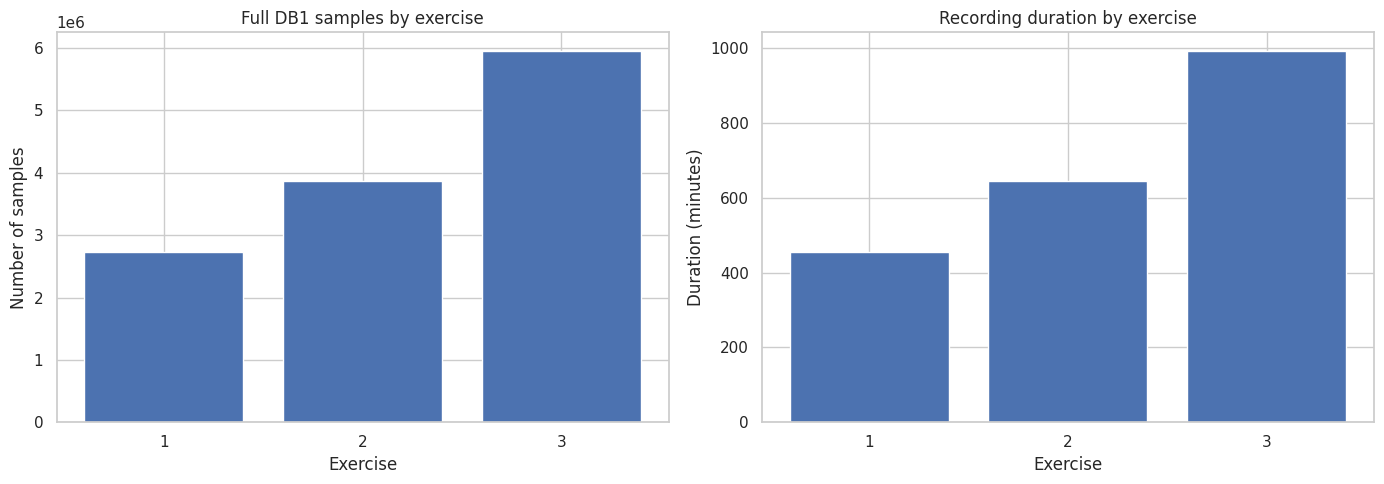

In [7]:
exercise_summary = (
    inventory_df
    .groupby(
        "Exercise",
        as_index=False,
    )
    .agg(
        subjects=(
            "Subject",
            "nunique",
        ),
        files=(
            "File",
            "count",
        ),
        total_samples=(
            "Samples",
            "sum",
        ),
        duration_min=(
            "Duration_min",
            "sum",
        ),
        active_samples=(
            "Active_samples",
            "sum",
        ),
        rest_samples=(
            "Rest_samples",
            "sum",
        ),
        active_fraction=(
            "Active_fraction",
            "mean",
        ),
        mean_active_emg_rms=(
            "Movement_EMG_RMS",
            "mean",
        ),
        mean_glove_range=(
            "Movement_glove_range",
            "mean",
        ),
    )
)

display(
    exercise_summary.round(
        4
    )
)

save_table(
    exercise_summary,
    "exercise_summary.csv",
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        14,
        5,
    ),
)

axes[0].bar(
    exercise_summary[
        "Exercise"
    ].astype(
        str
    ),
    exercise_summary[
        "total_samples"
    ],
)

axes[0].set_title(
    "Full DB1 samples by exercise"
)

axes[0].set_xlabel(
    "Exercise"
)

axes[0].set_ylabel(
    "Number of samples"
)

axes[1].bar(
    exercise_summary[
        "Exercise"
    ].astype(
        str
    ),
    exercise_summary[
        "duration_min"
    ],
)

axes[1].set_title(
    "Recording duration by exercise"
)

axes[1].set_xlabel(
    "Exercise"
)

axes[1].set_ylabel(
    "Duration (minutes)"
)

plt.tight_layout()

save_figure(
    "exercise_samples_duration.png"
)

plt.show()

## B2. Subject × exercise duration heatmap

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/subject_exercise_duration_heatmap.png


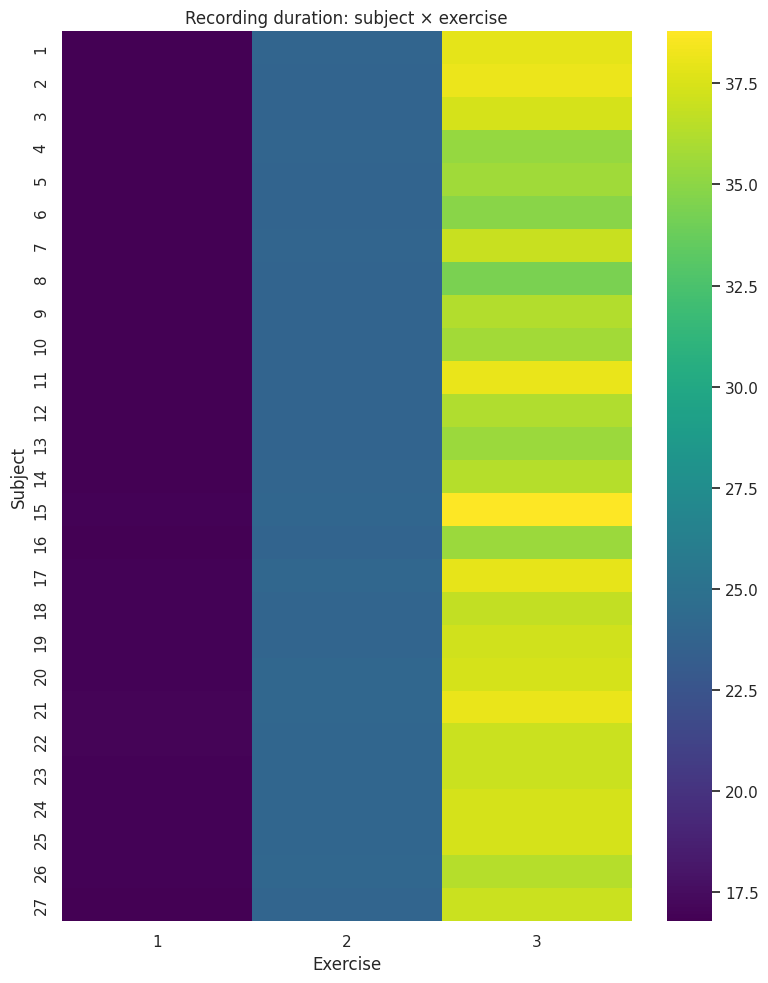

In [8]:
duration_pivot = (
    inventory_df
    .pivot(
        index="Subject",
        columns="Exercise",
        values="Duration_min",
    )
)

plt.figure(
    figsize=(
        8,
        10,
    )
)

sns.heatmap(
    duration_pivot,
    cmap="viridis",
    annot=False,
)

plt.title(
    "Recording duration: subject × exercise"
)

plt.xlabel(
    "Exercise"
)

plt.ylabel(
    "Subject"
)

plt.tight_layout()

save_figure(
    "subject_exercise_duration_heatmap.png"
)

plt.show()

# C. Movement-label and repetition coverage

## C1. Discover movement labels directly from the dataset

No hard-coded assumption is made about how many active labels belong to each exercise.

The table reports:

- movement label;
- exercise in which it occurs;
- exact sample count;
- duration;
- number of subjects containing that movement.

,Movement_label,Exercise,Samples,Duration_min,Subjects_present
0,1,"1,2,3",303720,50.620000,27
1,2,"1,2,3",299072,49.845333,27
2,3,"1,2,3",307321,51.220167,27
3,4,"1,2,3",290830,48.471667,27
4,5,"1,2,3",287942,47.990333,27
5,6,"1,2,3",292612,48.768667,27
6,7,"1,2,3",298404,49.734000,27
7,8,"1,2,3",303280,50.546667,27
8,9,"1,2,3",297929,49.654833,27
9,10,"1,2,3",290622,48.437000,27


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/movement_label_summary.csv
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/all_movement_sample_counts.png


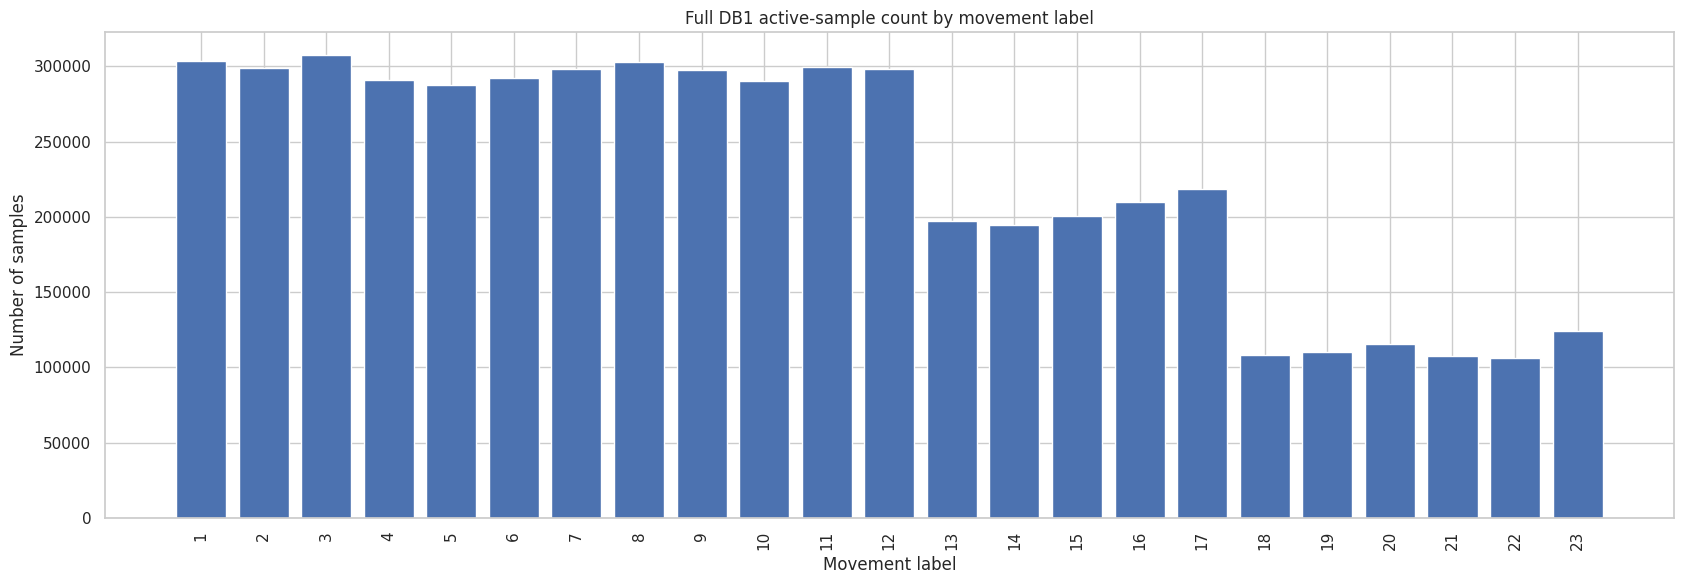

In [9]:
movement_rows = []

for label in sorted(
    movement_sample_counts
):
    if label == 0:
        continue

    exercises = sorted(
        movement_exercises[
            label
        ]
    )

    subjects = sorted(
        movement_subjects[
            label
        ]
    )

    count = int(
        movement_sample_counts[
            label
        ]
    )

    movement_rows.append(
        {
            "Movement_label": (
                label
            ),
            "Exercise": (
                ",".join(
                    map(
                        str,
                        exercises,
                    )
                )
            ),
            "Samples": (
                count
            ),
            "Duration_min": (
                count
                / FS
                / 60
            ),
            "Subjects_present": (
                len(
                    subjects
                )
            ),
        }
    )

movement_df = pd.DataFrame(
    movement_rows
)

display(
    movement_df
)

save_table(
    movement_df,
    "movement_label_summary.csv",
)

plt.figure(
    figsize=(
        17,
        6,
    )
)

plt.bar(
    movement_df[
        "Movement_label"
    ].astype(
        str
    ),
    movement_df[
        "Samples"
    ],
)

plt.title(
    "Full DB1 active-sample count by movement label"
)

plt.xlabel(
    "Movement label"
)

plt.ylabel(
    "Number of samples"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

save_figure(
    "all_movement_sample_counts.png"
)

plt.show()

## C2. Movement labels by exercise

In [10]:
exercise_movement_rows = []

for exercise in EXERCISES:
    labels_for_exercise = (
        movement_df.loc[
            movement_df[
                "Exercise"
            ].apply(
                lambda value:
                str(exercise)
                in value.split(",")
            )
        ]
    )

    exercise_movement_rows.append(
        {
            "Exercise": (
                exercise
            ),
            "Number_of_active_labels": (
                len(
                    labels_for_exercise
                )
            ),
            "Minimum_label": (
                labels_for_exercise[
                    "Movement_label"
                ].min()
            ),
            "Maximum_label": (
                labels_for_exercise[
                    "Movement_label"
                ].max()
            ),
            "Labels": (
                ", ".join(
                    map(
                        str,
                        labels_for_exercise[
                            "Movement_label"
                        ].tolist(),
                    )
                )
            ),
        }
    )

exercise_movement_df = (
    pd.DataFrame(
        exercise_movement_rows
    )
)

display(
    exercise_movement_df
)

save_table(
    exercise_movement_df,
    "movement_labels_by_exercise.csv",
)

,Exercise,Number_of_active_labels,Minimum_label,Maximum_label,Labels
0,1,12,1,12,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
1,2,17,1,17,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,..."
2,3,23,1,23,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,..."


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/movement_labels_by_exercise.csv


## C3. Repetition coverage

This checks how many unique repetitions are present for every:

```text
subject × exercise × active movement
```

The notebook does not assume that a particular repetition number is guaranteed; it reports what is actually present.

In [11]:
coverage_rows = []

for (
    subject,
    exercise,
    movement,
), repetitions in sorted(
    subject_movement_repetitions.items()
):
    repetitions = sorted(
        repetition
        for repetition
        in repetitions
        if repetition > 0
    )

    coverage_rows.append(
        {
            "Subject": (
                subject
            ),
            "Exercise": (
                exercise
            ),
            "Movement": (
                movement
            ),
            "Repetitions_present": (
                len(
                    repetitions
                )
            ),
            "Minimum_repetition": (
                min(
                    repetitions
                )
                if repetitions
                else np.nan
            ),
            "Maximum_repetition": (
                max(
                    repetitions
                )
                if repetitions
                else np.nan
            ),
            "Repetition_list": (
                ",".join(
                    map(
                        str,
                        repetitions,
                    )
                )
            ),
        }
    )

coverage_df = pd.DataFrame(
    coverage_rows
)

display(
    coverage_df.head(
        20
    )
)

print(
    "Repetition-count distribution:"
)

display(
    coverage_df[
        "Repetitions_present"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Repetitions_present"
    )
    .reset_index(
        name="Subject_movement_pairs"
    )
)

save_table(
    coverage_df,
    "repetition_coverage.csv",
)

,Subject,Exercise,Movement,Repetitions_present,Minimum_repetition,Maximum_repetition,Repetition_list
0,1,1,1,10,1,10,"1,2,3,4,5,6,7,8,9,10"
1,1,1,2,10,1,10,"1,2,3,4,5,6,7,8,9,10"
2,1,1,3,10,1,10,"1,2,3,4,5,6,7,8,9,10"
3,1,1,4,10,1,10,"1,2,3,4,5,6,7,8,9,10"
4,1,1,5,10,1,10,"1,2,3,4,5,6,7,8,9,10"
5,1,1,6,10,1,10,"1,2,3,4,5,6,7,8,9,10"
6,1,1,7,10,1,10,"1,2,3,4,5,6,7,8,9,10"
7,1,1,8,10,1,10,"1,2,3,4,5,6,7,8,9,10"
8,1,1,9,10,1,10,"1,2,3,4,5,6,7,8,9,10"
9,1,1,10,10,1,10,"1,2,3,4,5,6,7,8,9,10"


Repetition-count distribution:


,Repetitions_present,Subject_movement_pairs
0,10,1404


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/repetition_coverage.csv


# D. Balanced full-dataset signal sample

The complete DB1 contains many signal samples. For descriptive plots, a balanced sample is drawn from **every file**.

This is only for efficient visualization/statistics.

Exact file/sample/duration/movement counts above still come from the complete dataset.

In [12]:
sampled_parts = []

for file_index, file_path in enumerate(
    mat_files
):
    data = load_db1(
        file_path
    )

    ids = parse_file_ids(
        file_path
    )

    row_count = len(
        data["emg"]
    )

    local_rng = (
        np.random.default_rng(
            RANDOM_STATE
            + file_index
        )
    )

    selected_rows = np.sort(
        local_rng.choice(
            row_count,
            size=min(
                EDA_ROWS_PER_FILE,
                row_count,
            ),
            replace=False,
        )
    )

    part = pd.DataFrame(
        np.column_stack(
            [
                data["emg"][
                    selected_rows
                ],
                data["glove"][
                    selected_rows
                ],
            ]
        ),
        columns=(
            EMG_COLUMNS
            + GLOVE_COLUMNS
        ),
    )

    labels = np.asarray(
        data[
            "restimulus"
        ][
            selected_rows
        ],
        dtype=np.int16,
    )

    repetitions = np.asarray(
        data[
            "rerepetition"
        ][
            selected_rows
        ],
        dtype=np.int16,
    )

    part[
        "Subject"
    ] = int(
        ids["subject"]
    )

    part[
        "Exercise"
    ] = int(
        ids["exercise"]
    )

    part[
        "Movement"
    ] = labels

    part[
        "Repetition"
    ] = repetitions

    part[
        "Activity"
    ] = np.where(
        labels > 0,
        "Movement",
        "Rest",
    )

    sampled_parts.append(
        part
    )

eda_df = pd.concat(
    sampled_parts,
    ignore_index=True,
)

eda_df[
    "EMG_RMS"
] = np.sqrt(
    np.mean(
        eda_df[
            EMG_COLUMNS
        ].to_numpy() ** 2,
        axis=1,
    )
)

eda_df[
    "EMG_MAV"
] = np.mean(
    np.abs(
        eda_df[
            EMG_COLUMNS
        ].to_numpy()
    ),
    axis=1,
)

print(
    "Balanced full-DB1 EDA table:",
    eda_df.shape,
)

print(
    "Subjects represented:",
    eda_df[
        "Subject"
    ].nunique(),
)

print(
    "Exercises represented:",
    sorted(
        eda_df[
            "Exercise"
        ].unique()
    ),
)

print(
    "Rows sampled per file:",
    EDA_ROWS_PER_FILE,
)

Balanced full-DB1 EDA table: (121500, 39)
Subjects represented: 27
Exercises represented: [np.int64(1), np.int64(2), np.int64(3)]
Rows sampled per file: 1500


# E. Full-dataset signal statistics

## E1. EMG descriptive statistics

In [13]:
emg_statistics = (
    describe_channels(
        eda_df,
        EMG_COLUMNS,
    )
    .reset_index()
    .rename(
        columns={
            "index":
            "Channel"
        }
    )
)

display(
    emg_statistics.round(
        5
    )
)

save_table(
    emg_statistics,
    "full_emg_descriptive_statistics.csv",
)

,Channel,mean,median,std,min,q25,q75,max,skewness
0,EMG_1,0.22918,0.0537,0.41338,0.0024,0.0024,0.27340,4.6655,3.66259
1,EMG_2,0.14151,0.0049,0.29952,0.0000,0.0024,0.14953,4.6631,4.55183
2,EMG_3,0.13031,0.0049,0.34959,0.0024,0.0024,0.09770,4.6606,6.10629
3,EMG_4,0.06564,0.0024,0.21302,0.0000,0.0024,0.02690,4.6655,8.64616
4,EMG_5,0.02287,0.0024,0.08446,0.0024,0.0024,0.00490,4.6631,19.40004
5,EMG_6,0.05730,0.0049,0.16415,0.0000,0.0024,0.04640,4.6655,8.99475
6,EMG_7,0.32117,0.1270,0.55736,0.0000,0.0244,0.36380,4.6655,3.90296
7,EMG_8,0.33327,0.1831,0.45973,0.0024,0.0635,0.41750,4.6680,3.60127
8,EMG_9,0.12890,0.0024,0.34281,0.0000,0.0024,0.09280,4.6631,5.74554
9,EMG_10,0.23479,0.1001,0.38834,0.0000,0.0122,0.28810,4.6655,4.16726


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/full_emg_descriptive_statistics.csv


## E2. Glove descriptive statistics

In [14]:
glove_statistics = (
    describe_channels(
        eda_df,
        GLOVE_COLUMNS,
    )
    .reset_index()
    .rename(
        columns={
            "index":
            "Channel"
        }
    )
)

display(
    glove_statistics.round(
        4
    )
)

save_table(
    glove_statistics,
    "full_glove_descriptive_statistics.csv",
)

,Channel,mean,median,std,min,q25,q75,max,skewness
0,GLOVE_1,131.9093,132.0000,27.7149,11.8748,115.0000,148.0000,255.0000,0.0976
1,GLOVE_2,111.6576,111.0000,15.6822,1.0000,102.5546,120.0000,214.4171,0.1985
2,GLOVE_3,111.1174,112.0000,14.5234,14.4165,105.0000,118.0000,188.0000,-0.3013
3,GLOVE_4,132.3182,131.0000,15.2832,69.0000,122.0000,142.0000,192.0000,0.2687
4,GLOVE_5,116.7952,119.0000,19.7970,22.0000,106.0000,129.0000,198.0000,-0.5608
5,GLOVE_6,91.0356,88.9638,34.4494,1.0000,65.0000,114.6863,212.0000,0.3536
6,GLOVE_7,85.2504,81.0000,20.4252,1.0000,74.0000,91.0000,255.0000,1.8617
7,GLOVE_8,103.9865,105.0000,19.4605,16.0000,93.5676,115.0000,174.0000,-0.3696
8,GLOVE_9,102.3264,103.0000,31.5692,20.0000,77.5377,125.0000,205.0000,0.1290
9,GLOVE_10,77.2251,75.0000,14.7813,1.0000,69.0000,83.0000,200.0000,0.9938


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/full_glove_descriptive_statistics.csv


## E3. Channel quality: near-constant and extreme-value checks

In [15]:
channel_quality_rows = []

for column in (
    EMG_COLUMNS
    + GLOVE_COLUMNS
):
    values = eda_df[
        column
    ].to_numpy()

    q1 = np.quantile(
        values,
        0.25,
    )

    q3 = np.quantile(
        values,
        0.75,
    )

    iqr = (
        q3 - q1
    )

    lower = (
        q1
        - 1.5 * iqr
    )

    upper = (
        q3
        + 1.5 * iqr
    )

    outlier_fraction = float(
        np.mean(
            (
                values < lower
            )
            |
            (
                values > upper
            )
        )
    )

    std = float(
        np.std(
            values
        )
    )

    channel_quality_rows.append(
        {
            "Channel": (
                column
            ),
            "Std": std,
            "Near_constant": (
                std < 1e-6
            ),
            "IQR_outlier_fraction": (
                outlier_fraction
            ),
        }
    )

channel_quality_df = (
    pd.DataFrame(
        channel_quality_rows
    )
)

display(
    channel_quality_df.round(
        6
    )
)

print(
    "Near-constant channels:",
    int(
        channel_quality_df[
            "Near_constant"
        ].sum()
    ),
)

save_table(
    channel_quality_df,
    "channel_quality.csv",
)

,Channel,Std,Near_constant,IQR_outlier_fraction
0,EMG_1,0.413379,False,0.098000
1,EMG_2,0.299520,False,0.122469
2,EMG_3,0.349584,False,0.150971
3,EMG_4,0.213017,False,0.190700
4,EMG_5,0.084459,False,0.226255
5,EMG_6,0.164151,False,0.131374
6,EMG_7,0.557359,False,0.093794
7,EMG_8,0.459725,False,0.075737
8,EMG_9,0.342806,False,0.149399
9,EMG_10,0.388337,False,0.078049


Near-constant channels: 0
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/channel_quality.csv


## E4. Representative EMG and glove distributions

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/representative_signal_distributions.png


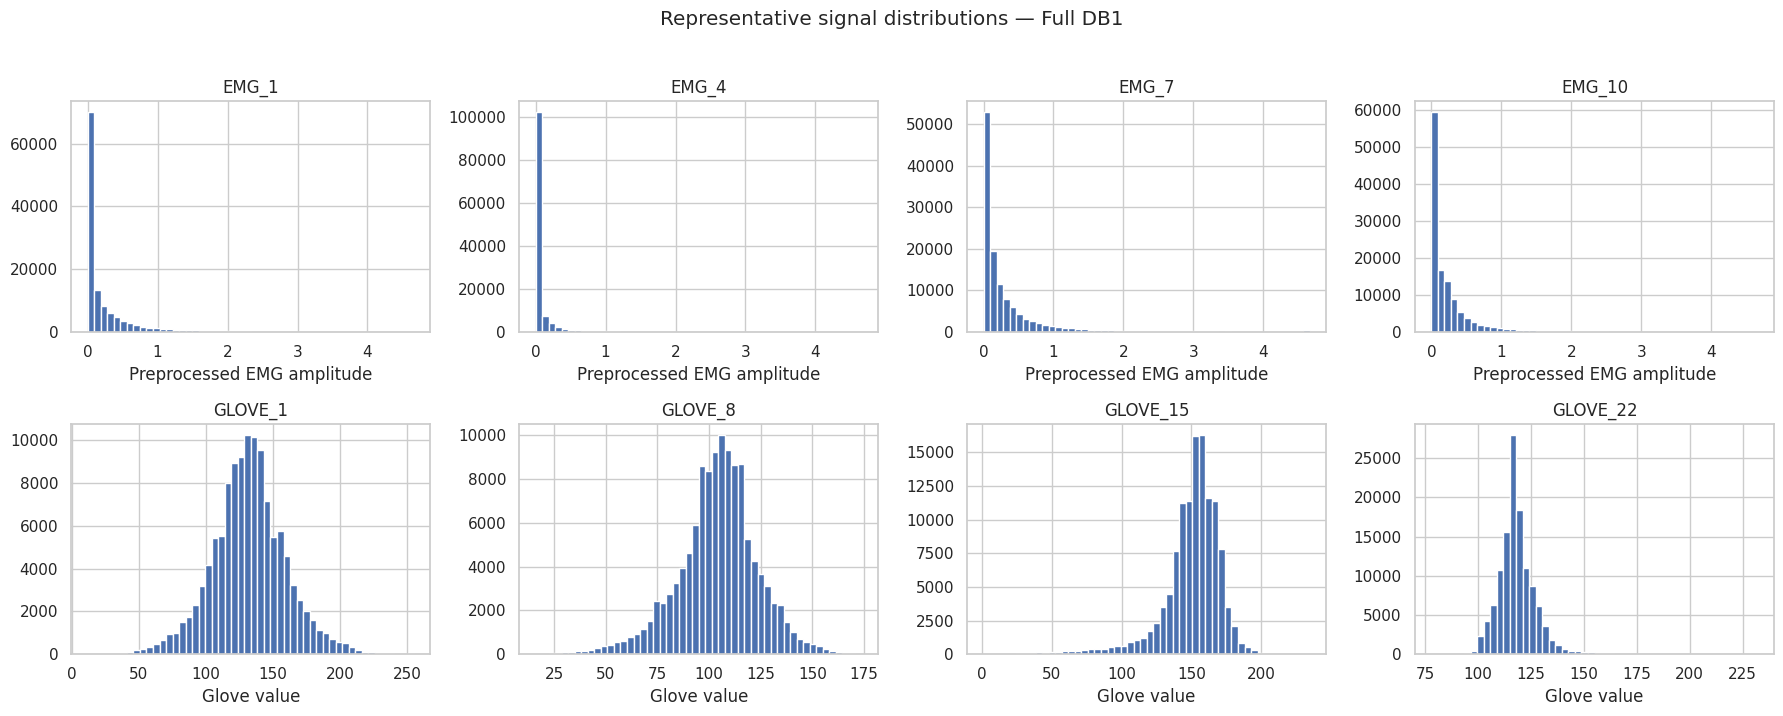

In [16]:
selected_emg = [
    "EMG_1",
    "EMG_4",
    "EMG_7",
    "EMG_10",
]

selected_glove = [
    "GLOVE_1",
    "GLOVE_8",
    "GLOVE_15",
    "GLOVE_22",
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(
        18,
        7,
    ),
)

for axis, column in zip(
    axes[0],
    selected_emg,
):
    axis.hist(
        eda_df[
            column
        ],
        bins=50,
    )

    axis.set_title(
        column
    )

    axis.set_xlabel(
        "Preprocessed EMG amplitude"
    )

for axis, column in zip(
    axes[1],
    selected_glove,
):
    axis.hist(
        eda_df[
            column
        ],
        bins=50,
    )

    axis.set_title(
        column
    )

    axis.set_xlabel(
        "Glove value"
    )

fig.suptitle(
    "Representative signal distributions — Full DB1",
    y=1.02,
)

plt.tight_layout()

save_figure(
    "representative_signal_distributions.png"
)

plt.show()

# F. Activity effects and exercise differences

## F1. Rest versus active movement EMG RMS

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/rest_vs_movement_emg_rms.png


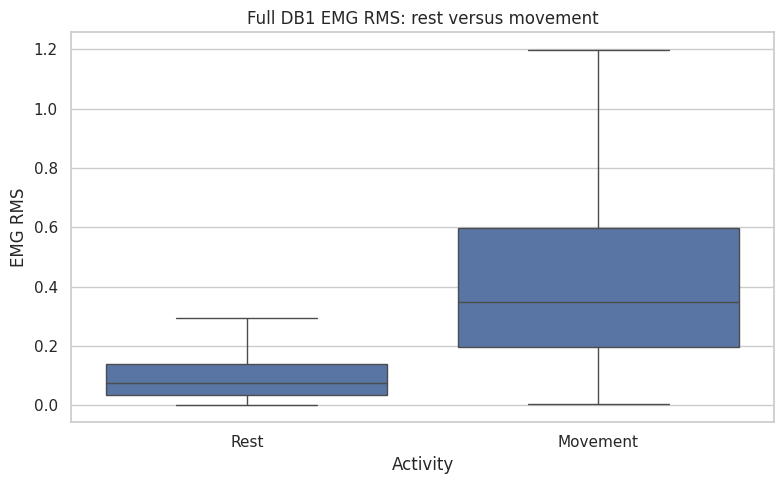

EMG_RMS                    EMG_MAV                  
             mean   median      std     mean   median      std
Activity                                                      
Movement  0.45810  0.34531  0.38647  0.31622  0.22754  0.28625
Rest      0.10054  0.07557  0.09563  0.05598  0.03977  0.05824

In [17]:
plot_sample = eda_df.sample(
    min(
        PLOT_SAMPLE_MAX,
        len(
            eda_df
        ),
    ),
    random_state=RANDOM_STATE,
)

plt.figure(
    figsize=(
        8,
        5,
    )
)

sns.boxplot(
    data=plot_sample,
    x="Activity",
    y="EMG_RMS",
    order=[
        "Rest",
        "Movement",
    ],
    showfliers=False,
)

plt.title(
    "Full DB1 EMG RMS: rest versus movement"
)

plt.xlabel(
    "Activity"
)

plt.ylabel(
    "EMG RMS"
)

plt.tight_layout()

save_figure(
    "rest_vs_movement_emg_rms.png"
)

plt.show()

activity_statistics = (
    eda_df
    .groupby(
        "Activity"
    )[
        [
            "EMG_RMS",
            "EMG_MAV",
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std",
        ]
    )
)

display(
    activity_statistics.round(
        5
    )
)

## F2. EMG RMS by exercise

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/active_emg_rms_by_exercise.png


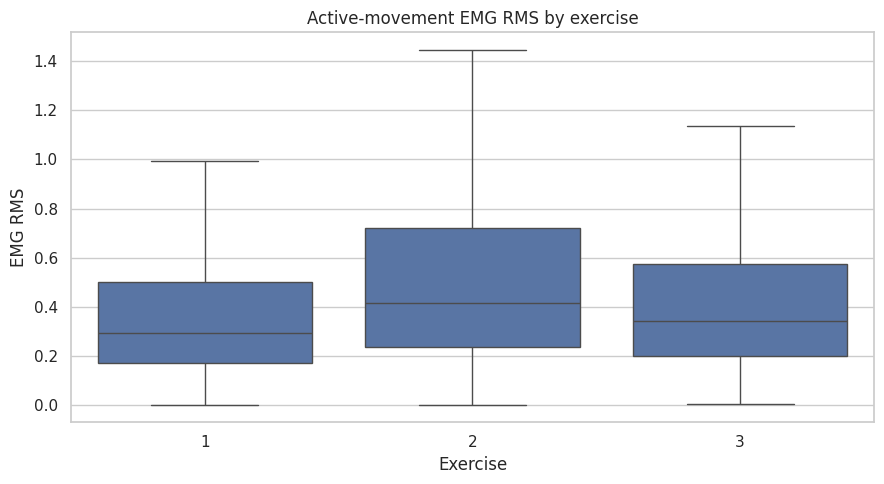

,mean,median,std
Exercise,,,
1,0.38829,0.29371,0.32574
2,0.54839,0.41747,0.45479
3,0.43837,0.34079,0.34860


In [18]:
active_eda = eda_df.loc[
    eda_df[
        "Activity"
    ] == "Movement"
].copy()

plt.figure(
    figsize=(
        9,
        5,
    )
)

sns.boxplot(
    data=active_eda.sample(
        min(
            PLOT_SAMPLE_MAX,
            len(
                active_eda
            ),
        ),
        random_state=RANDOM_STATE,
    ),
    x="Exercise",
    y="EMG_RMS",
    showfliers=False,
)

plt.title(
    "Active-movement EMG RMS by exercise"
)

plt.xlabel(
    "Exercise"
)

plt.ylabel(
    "EMG RMS"
)

plt.tight_layout()

save_figure(
    "active_emg_rms_by_exercise.png"
)

plt.show()

display(
    active_eda
    .groupby(
        "Exercise"
    )[
        "EMG_RMS"
    ]
    .agg(
        [
            "mean",
            "median",
            "std",
        ]
    )
    .round(
        5
    )
)

# G. Between-subject variability

,Subject,total_samples,total_duration_min,mean_active_emg_rms,mean_glove_range,mean_active_fraction
0,1,471483,78.5805,0.4516,117.3617,0.3812
1,2,472501,78.7502,0.6504,122.5852,0.4065
2,3,467777,77.9628,0.4296,108.5257,0.3929
3,4,455868,75.9780,0.3309,100.8794,0.4598
4,5,457542,76.2570,0.5762,120.4891,0.4873
5,6,453169,75.5282,0.7234,110.2162,0.4621
6,7,465343,77.5572,0.5385,114.6376,0.4209
7,8,449730,74.9550,0.4271,109.1747,0.4025
8,9,461355,76.8925,0.4313,109.7205,0.4230
9,10,457928,76.3213,0.5065,114.4648,0.4357


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/between_subject_variability.png


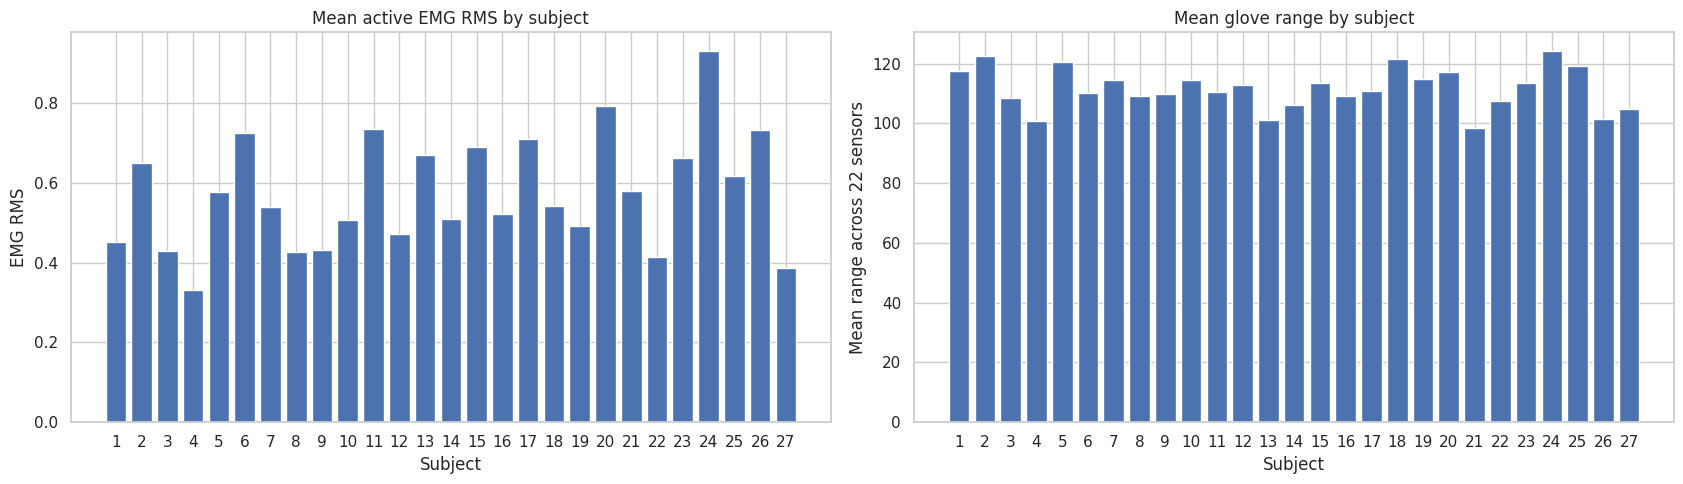

Between-subject active EMG RMS CV: 24.89%
Between-subject glove-range CV: 6.21%
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/subject_summary.csv


In [19]:
subject_summary = (
    inventory_df
    .groupby(
        "Subject",
        as_index=False,
    )
    .agg(
        total_samples=(
            "Samples",
            "sum",
        ),
        total_duration_min=(
            "Duration_min",
            "sum",
        ),
        mean_active_emg_rms=(
            "Movement_EMG_RMS",
            "mean",
        ),
        mean_glove_range=(
            "Movement_glove_range",
            "mean",
        ),
        mean_active_fraction=(
            "Active_fraction",
            "mean",
        ),
    )
)

display(
    subject_summary.round(
        4
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        17,
        5,
    ),
)

axes[0].bar(
    subject_summary[
        "Subject"
    ].astype(
        str
    ),
    subject_summary[
        "mean_active_emg_rms"
    ],
)

axes[0].set_title(
    "Mean active EMG RMS by subject"
)

axes[0].set_xlabel(
    "Subject"
)

axes[0].set_ylabel(
    "EMG RMS"
)

axes[1].bar(
    subject_summary[
        "Subject"
    ].astype(
        str
    ),
    subject_summary[
        "mean_glove_range"
    ],
)

axes[1].set_title(
    "Mean glove range by subject"
)

axes[1].set_xlabel(
    "Subject"
)

axes[1].set_ylabel(
    "Mean range across 22 sensors"
)

plt.tight_layout()

save_figure(
    "between_subject_variability.png"
)

plt.show()

emg_cv = (
    100
    * subject_summary[
        "mean_active_emg_rms"
    ].std()
    / subject_summary[
        "mean_active_emg_rms"
    ].mean()
)

glove_cv = (
    100
    * subject_summary[
        "mean_glove_range"
    ].std()
    / subject_summary[
        "mean_glove_range"
    ].mean()
)

print(
    "Between-subject active EMG RMS CV:",
    f"{emg_cv:.2f}%",
)

print(
    "Between-subject glove-range CV:",
    f"{glove_cv:.2f}%",
)

save_table(
    subject_summary,
    "subject_summary.csv",
)

# H. Correlation structure

## H1. EMG-channel correlation

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/emg_channel_correlation.png


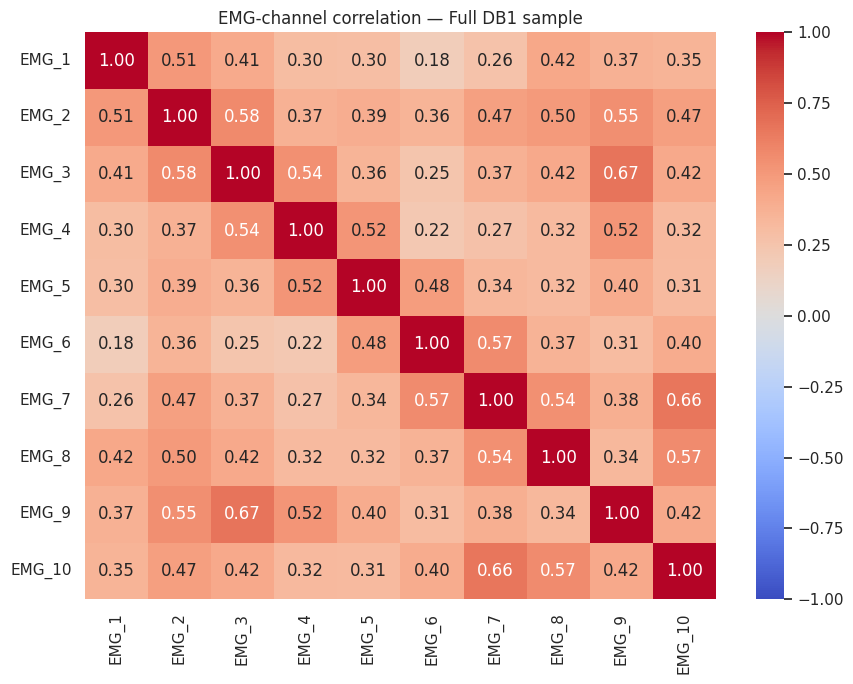

In [20]:
correlation_source = (
    eda_df[
        EMG_COLUMNS
    ]
    .sample(
        min(
            CORRELATION_SAMPLE_MAX,
            len(
                eda_df
            ),
        ),
        random_state=RANDOM_STATE,
    )
)

emg_correlation = (
    correlation_source
    .corr()
)

plt.figure(
    figsize=(
        9,
        7,
    )
)

sns.heatmap(
    emg_correlation,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
)

plt.title(
    "EMG-channel correlation — Full DB1 sample"
)

plt.tight_layout()

save_figure(
    "emg_channel_correlation.png"
)

plt.show()

## H2. Absolute EMG versus glove correlation

This is descriptive only. It does not replace temporal regression.

The relationship is averaged over the balanced EDA sample rather than interpreted causally.

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/emg_glove_correlation.png


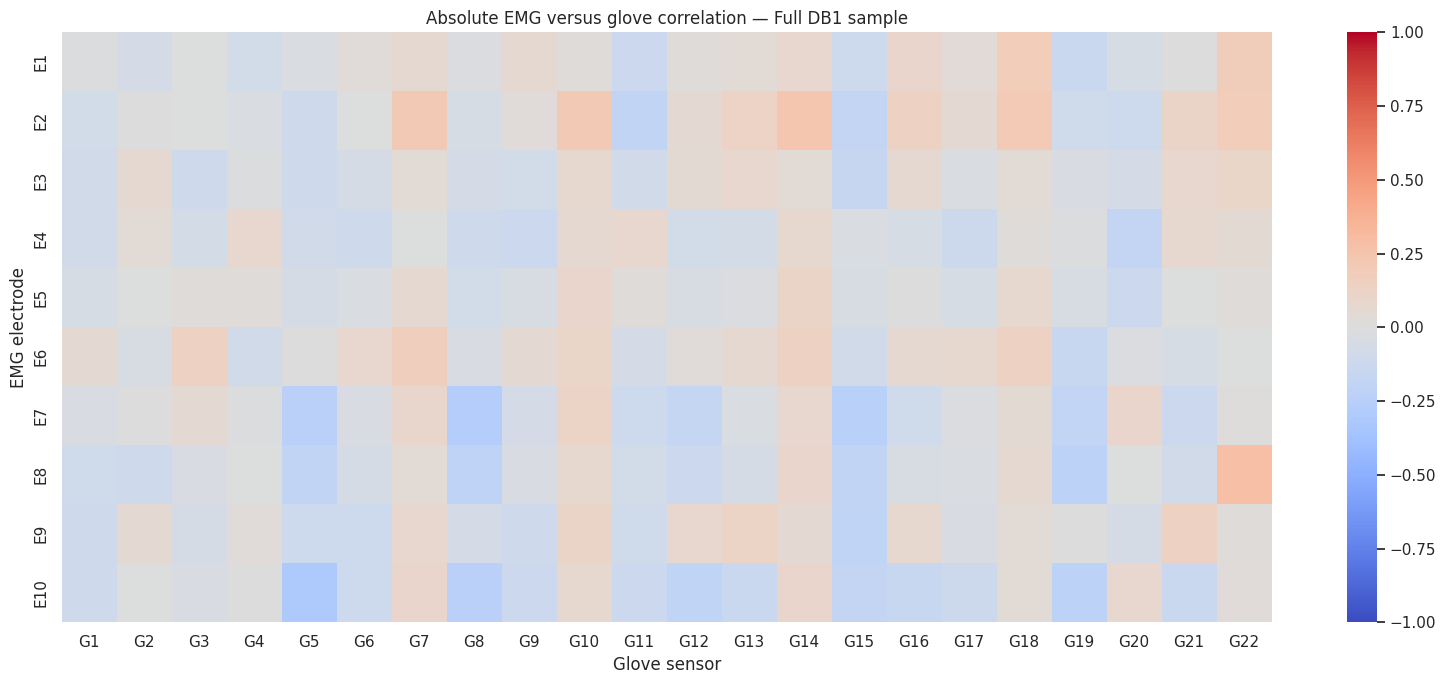

Maximum absolute EMG–glove correlation: 0.3067


In [21]:
active_corr_df = (
    eda_df.loc[
        eda_df[
            "Activity"
        ] == "Movement"
    ]
    .sample(
        min(
            CORRELATION_SAMPLE_MAX,
            (
                eda_df[
                    "Activity"
                ]
                == "Movement"
            ).sum(),
        ),
        random_state=RANDOM_STATE,
    )
)

emg_absolute = np.abs(
    active_corr_df[
        EMG_COLUMNS
    ].to_numpy()
)

glove_values = (
    active_corr_df[
        GLOVE_COLUMNS
    ].to_numpy()
)

combined = np.column_stack(
    [
        emg_absolute,
        glove_values,
    ]
)

correlation = np.corrcoef(
    combined.T
)

emg_glove_correlation = (
    correlation[
        :N_EMG,
        N_EMG:
    ]
)

plt.figure(
    figsize=(
        16,
        7,
    )
)

sns.heatmap(
    emg_glove_correlation,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    xticklabels=[
        f"G{i}"
        for i in range(
            1,
            N_GLOVE + 1,
        )
    ],
    yticklabels=[
        f"E{i}"
        for i in range(
            1,
            N_EMG + 1,
        )
    ],
)

plt.title(
    "Absolute EMG versus glove correlation — Full DB1 sample"
)

plt.xlabel(
    "Glove sensor"
)

plt.ylabel(
    "EMG electrode"
)

plt.tight_layout()

save_figure(
    "emg_glove_correlation.png"
)

plt.show()

print(
    "Maximum absolute EMG–glove correlation:",
    round(
        float(
            np.nanmax(
                np.abs(
                    emg_glove_correlation
                )
            )
        ),
        4,
    ),
)

# I. Temporal examples from all three exercises

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/temporal_examples_all_exercises.png


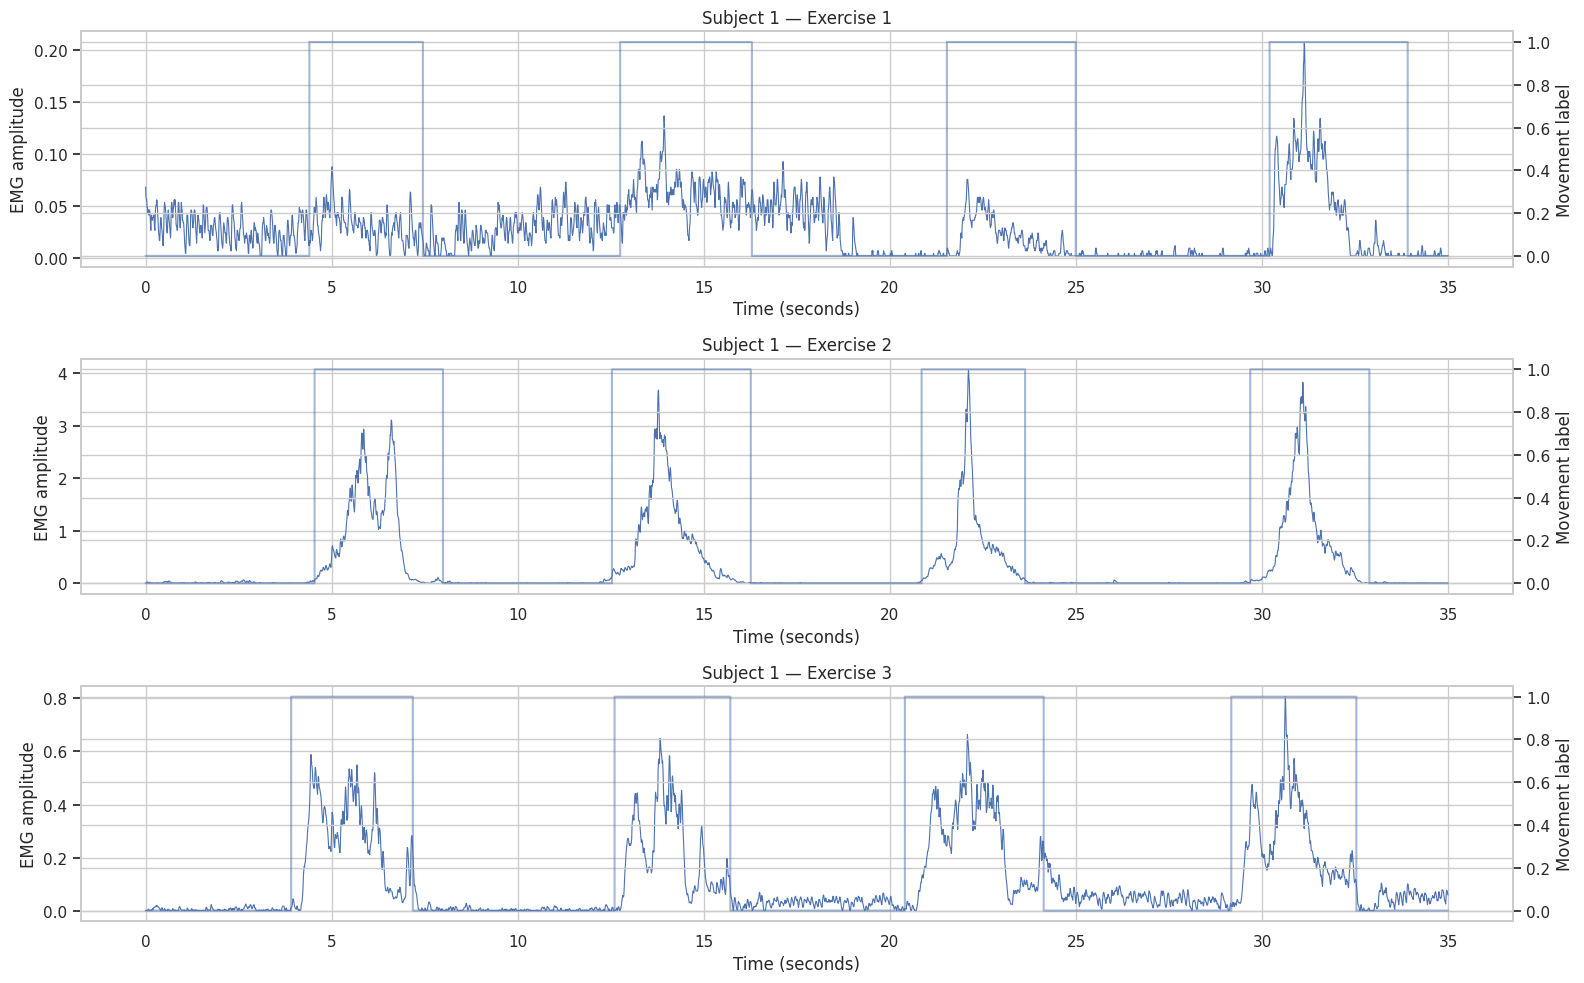

In [22]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(
        16,
        10,
    ),
    sharex=False,
)

SHOW_SECONDS = 35

for axis, exercise in zip(
    axes,
    EXERCISES,
):
    example_path = next(
        path
        for path in mat_files
        if (
            parse_file_ids(
                path
            )[
                "subject"
            ] == 1
            and parse_file_ids(
                path
            )[
                "exercise"
            ] == exercise
        )
    )

    example = load_db1(
        example_path
    )

    stop = min(
        len(
            example[
                "emg"
            ]
        ),
        SHOW_SECONDS
        * FS,
    )

    time_axis = (
        np.arange(
            stop
        )
        / FS
    )

    axis.plot(
        time_axis,
        example[
            "emg"
        ][
            :stop,
            0,
        ],
        linewidth=0.8,
        label="EMG E1",
    )

    ax2 = (
        axis.twinx()
    )

    ax2.step(
        time_axis,
        example[
            "restimulus"
        ][
            :stop
        ],
        where="post",
        alpha=0.5,
        label="Movement label",
    )

    axis.set_title(
        f"Subject 1 — Exercise {exercise}"
    )

    axis.set_ylabel(
        "EMG amplitude"
    )

    ax2.set_ylabel(
        "Movement label"
    )

    axis.set_xlabel(
        "Time (seconds)"
    )

plt.tight_layout()

save_figure(
    "temporal_examples_all_exercises.png"
)

plt.show()

# J. PCA view of full-dataset EMG activity

PCA is used only as an exploratory visualization of the 10-channel EMG sample.

The points are colored by **exercise**, because displaying every movement label on one PCA plot would be visually crowded.

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/full_db1_emg_pca.png


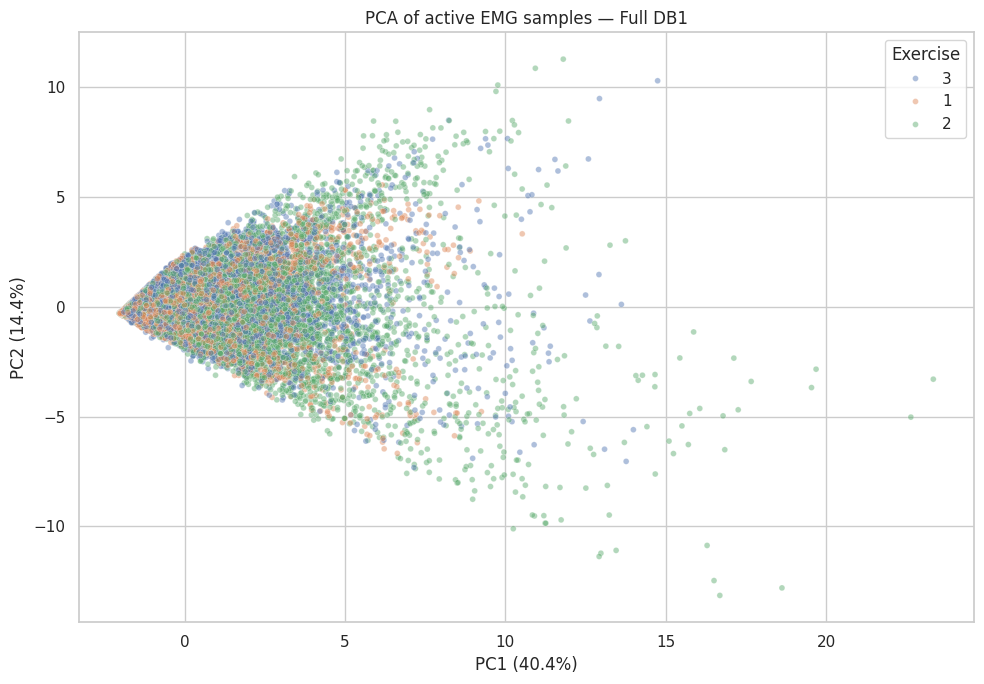

PC1 + PC2 explained variance: 54.78%


In [23]:
pca_source = (
    eda_df.loc[
        eda_df[
            "Activity"
        ] == "Movement"
    ]
    .sample(
        min(
            PCA_SAMPLE_MAX,
            (
                eda_df[
                    "Activity"
                ]
                == "Movement"
            ).sum(),
        ),
        random_state=RANDOM_STATE,
    )
    .copy()
)

X_pca = (
    StandardScaler()
    .fit_transform(
        pca_source[
            EMG_COLUMNS
        ]
    )
)

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

components = (
    pca.fit_transform(
        X_pca
    )
)

pca_plot_df = pd.DataFrame(
    {
        "PC1": (
            components[
                :,
                0
            ]
        ),
        "PC2": (
            components[
                :,
                1
            ]
        ),
        "Exercise": (
            pca_source[
                "Exercise"
            ]
            .astype(
                str
            )
            .to_numpy()
        ),
    }
)

plt.figure(
    figsize=(
        10,
        7,
    )
)

sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Exercise",
    alpha=0.45,
    s=18,
)

plt.title(
    "PCA of active EMG samples — Full DB1"
)

plt.xlabel(
    (
        "PC1 "
        f"({pca.explained_variance_ratio_[0] * 100:.1f}%)"
    )
)

plt.ylabel(
    (
        "PC2 "
        f"({pca.explained_variance_ratio_[1] * 100:.1f}%)"
    )
)

plt.tight_layout()

save_figure(
    "full_db1_emg_pca.png"
)

plt.show()

print(
    "PC1 + PC2 explained variance:",
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%",
)

# K. Full-dataset EDA findings

In [24]:
full_findings = pd.DataFrame(
    {
        "EDA finding": [
            "Dataset coverage",
            "Signal alignment",
            "Missing/infinite data",
            "Rest vs movement",
            "Between-subject variability",
            "Exercise differences",
            "Movement coverage",
            "Repetition structure",
            "EMG correlation",
            "EMG–glove relationship",
        ],
        "Evidence generated in notebook": [
            (
                f"{inventory_df['Subject'].nunique()} "
                "subjects across "
                f"{inventory_df['Exercise'].nunique()} exercises"
            ),
            (
                f"{inventory_df['Aligned'].sum()}/"
                f"{len(inventory_df)} files aligned"
            ),
            (
                f"{int(inventory_df['Missing_values'].sum())} missing, "
                f"{int(inventory_df['Infinite_values'].sum())} infinite"
            ),
            "EMG RMS compared for rest and active samples",
            (
                f"Active EMG RMS CV = {emg_cv:.2f}%"
            ),
            "Exercise-wise sample, duration, EMG, and glove summaries",
            (
                f"{len(active_labels)} active labels discovered"
            ),
            "Unique repetition count reported per subject × movement",
            "10 × 10 EMG correlation heatmap",
            (
                "10 EMG electrodes × 22 glove sensors "
                "descriptive correlation heatmap"
            ),
        ],
    }
)

display(
    full_findings
)

save_table(
    full_findings,
    "full_eda_findings.csv",
)

,EDA finding,Evidence generated in notebook
0,Dataset coverage,27 subjects across 3 exercises
1,Signal alignment,81/81 files aligned
2,Missing/infinite data,"0 missing, 0 infinite"
3,Rest vs movement,EMG RMS compared for rest and active samples
4,Between-subject variability,Active EMG RMS CV = 24.89%
5,Exercise differences,"Exercise-wise sample, duration, EMG, and glove..."
6,Movement coverage,23 active labels discovered
7,Repetition structure,Unique repetition count reported per subject ×...
8,EMG correlation,10 × 10 EMG correlation heatmap
9,EMG–glove relationship,10 EMG electrodes × 22 glove sensors descripti...


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/full_eda_findings.csv


# L. Downstream subset: 8 subjects × 3 wrist movements

The full EDA above describes the **entire DB1 dataset**.

The remainder of the notebook now focuses on the subset later used for wrist-angle regression:

```text
Subjects = S1–S8
Exercise = 2

Movement 13 = WF
Movement 16 = WUD
Movement 17 = WECH
```

This does **not** redefine the dataset. It only documents the experimental subset selected after full-dataset exploration.

## L1. Build exact selected-subset inventory

In [25]:
selected_rows = []
selected_signal_parts = []

selected_paths = [
    path
    for path in mat_files
    if (
        parse_file_ids(
            path
        )[
            "subject"
        ]
        in SELECTED_SUBJECTS
        and parse_file_ids(
            path
        )[
            "exercise"
        ]
        == SELECTED_EXERCISE
    )
]

assert (
    len(
        selected_paths
    )
    == len(
        SELECTED_SUBJECTS
    )
)

for file_index, file_path in enumerate(
    selected_paths
):
    ids = parse_file_ids(
        file_path
    )

    data = load_db1(
        file_path
    )

    labels = np.asarray(
        data[
            "restimulus"
        ],
        dtype=np.int16,
    )

    repetitions = np.asarray(
        data[
            "rerepetition"
        ],
        dtype=np.int16,
    )

    emg = np.asarray(
        data[
            "emg"
        ]
    )

    glove = np.asarray(
        data[
            "glove"
        ]
    )

    subset_mask = np.isin(
        labels,
        list(
            SELECTED_MOVEMENTS
        ),
    )

    for movement, movement_name in (
        SELECTED_MOVEMENTS.items()
    ):
        movement_mask = (
            labels
            == movement
        )

        movement_repetitions = sorted(
            int(
                value
            )
            for value in np.unique(
                repetitions[
                    movement_mask
                ]
            )
            if value > 0
        )

        count = int(
            movement_mask.sum()
        )

        selected_rows.append(
            {
                "Subject": int(
                    ids[
                        "subject"
                    ]
                ),
                "Exercise": (
                    SELECTED_EXERCISE
                ),
                "Movement_label": (
                    movement
                ),
                "Movement": (
                    movement_name
                ),
                "Samples": (
                    count
                ),
                "Duration_min": (
                    count
                    / FS
                    / 60
                ),
                "Repetitions_present": (
                    len(
                        movement_repetitions
                    )
                ),
                "Repetition_list": (
                    ",".join(
                        map(
                            str,
                            movement_repetitions,
                        )
                    )
                ),
            }
        )

    selected_indices = np.flatnonzero(
        subset_mask
    )

    local_rng = np.random.default_rng(
        RANDOM_STATE
        + 5000
        + file_index
    )

    if len(
        selected_indices
    ):
        chosen = np.sort(
            local_rng.choice(
                selected_indices,
                size=min(
                    6000,
                    len(
                        selected_indices
                    ),
                ),
                replace=False,
            )
        )

        part = pd.DataFrame(
            np.column_stack(
                [
                    emg[
                        chosen
                    ],
                    glove[
                        chosen
                    ],
                ]
            ),
            columns=(
                EMG_COLUMNS
                + GLOVE_COLUMNS
            ),
        )

        part[
            "Subject"
        ] = int(
            ids[
                "subject"
            ]
        )

        part[
            "Movement_label"
        ] = labels[
            chosen
        ]

        part[
            "Movement"
        ] = [
            SELECTED_MOVEMENTS[
                int(
                    value
                )
            ]
            for value in labels[
                chosen
            ]
        ]

        part[
            "Repetition"
        ] = repetitions[
            chosen
        ]

        selected_signal_parts.append(
            part
        )

selected_inventory = (
    pd.DataFrame(
        selected_rows
    )
    .sort_values(
        [
            "Subject",
            "Movement_label",
        ]
    )
    .reset_index(
        drop=True
    )
)

selected_eda_df = (
    pd.concat(
        selected_signal_parts,
        ignore_index=True,
    )
)

selected_eda_df[
    "EMG_RMS"
] = np.sqrt(
    np.mean(
        selected_eda_df[
            EMG_COLUMNS
        ].to_numpy() ** 2,
        axis=1,
    )
)

display(
    selected_inventory
)

print(
    "Selected subset samples:",
    f"{selected_inventory['Samples'].sum():,}",
)

print(
    "Selected active duration:",
    (
        f"{selected_inventory['Duration_min'].sum():.2f} "
        "minutes"
    ),
)

save_table(
    selected_inventory,
    "selected_8_subject_3_movement_inventory.csv",
)

,Subject,Exercise,Movement_label,Movement,Samples,Duration_min,Repetitions_present,Repetition_list
0,1,2,13,WF,3118,0.519667,10,"1,2,3,4,5,6,7,8,9,10"
1,1,2,16,WUD,3391,0.565167,10,"1,2,3,4,5,6,7,8,9,10"
2,1,2,17,WECH,4222,0.703667,10,"1,2,3,4,5,6,7,8,9,10"
3,2,2,13,WF,3648,0.608000,10,"1,2,3,4,5,6,7,8,9,10"
4,2,2,16,WUD,3979,0.663167,10,"1,2,3,4,5,6,7,8,9,10"
5,2,2,17,WECH,4182,0.697000,10,"1,2,3,4,5,6,7,8,9,10"
6,3,2,13,WF,4032,0.672000,10,"1,2,3,4,5,6,7,8,9,10"
7,3,2,16,WUD,3398,0.566333,10,"1,2,3,4,5,6,7,8,9,10"
8,3,2,17,WECH,2815,0.469167,10,"1,2,3,4,5,6,7,8,9,10"
9,4,2,13,WF,3326,0.554333,10,"1,2,3,4,5,6,7,8,9,10"


Selected subset samples: 89,345
Selected active duration: 14.89 minutes
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/selected_8_subject_3_movement_inventory.csv


## L2. Selected-subset sample counts by movement

,Movement_label,Movement,Samples,Duration_min,Subjects,Mean_repetitions
0,13,WF,27879,4.6465,8,10.0
1,16,WUD,31110,5.1850,8,10.0
2,17,WECH,30356,5.0593,8,10.0


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/selected_subset_movement_counts.png


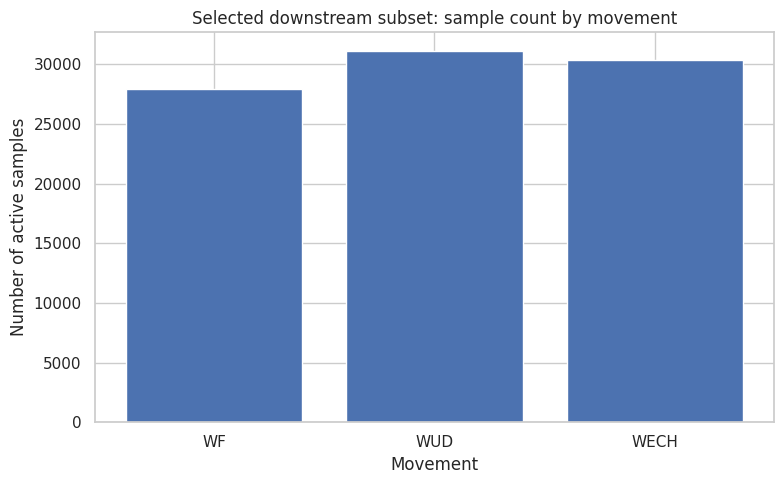

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/selected_subset_movement_summary.csv


In [26]:
selected_movement_summary = (
    selected_inventory
    .groupby(
        [
            "Movement_label",
            "Movement",
        ],
        as_index=False,
    )
    .agg(
        Samples=(
            "Samples",
            "sum",
        ),
        Duration_min=(
            "Duration_min",
            "sum",
        ),
        Subjects=(
            "Subject",
            "nunique",
        ),
        Mean_repetitions=(
            "Repetitions_present",
            "mean",
        ),
    )
)

display(
    selected_movement_summary.round(
        4
    )
)

plt.figure(
    figsize=(
        8,
        5,
    )
)

plt.bar(
    selected_movement_summary[
        "Movement"
    ],
    selected_movement_summary[
        "Samples"
    ],
)

plt.title(
    "Selected downstream subset: sample count by movement"
)

plt.xlabel(
    "Movement"
)

plt.ylabel(
    "Number of active samples"
)

plt.tight_layout()

save_figure(
    "selected_subset_movement_counts.png"
)

plt.show()

save_table(
    selected_movement_summary,
    "selected_subset_movement_summary.csv",
)

## L3. Selected-subset samples by subject and movement

Movement,WECH,WF,WUD
Subject,,,
1,4222,3118,3391
2,4182,3648,3979
3,2815,4032,3398
4,3842,3326,4655
5,4197,3076,4367
6,4210,4114,3823
7,4351,3520,4302
8,2537,3045,3195


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/selected_subject_movement_heatmap.png


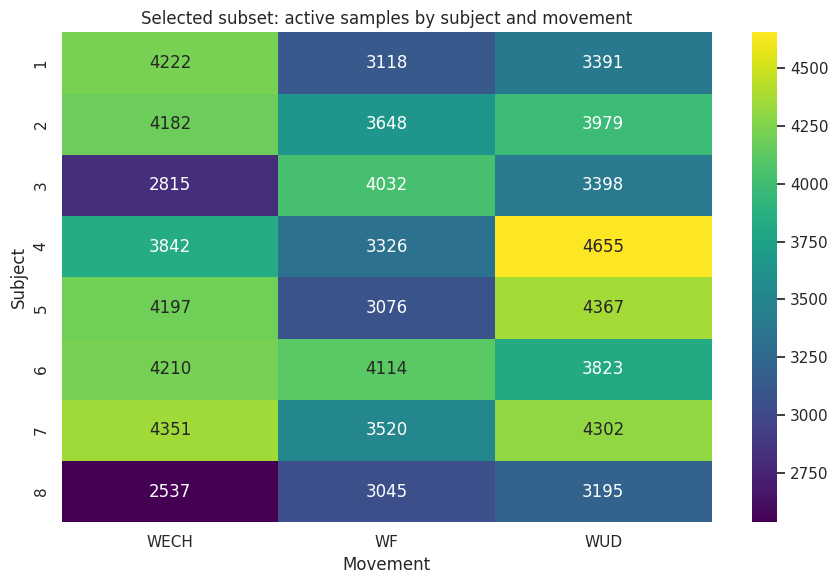

In [27]:
selected_count_pivot = (
    selected_inventory
    .pivot(
        index="Subject",
        columns="Movement",
        values="Samples",
    )
)

display(
    selected_count_pivot
)

plt.figure(
    figsize=(
        9,
        6,
    )
)

sns.heatmap(
    selected_count_pivot,
    annot=True,
    fmt=".0f",
    cmap="viridis",
)

plt.title(
    "Selected subset: active samples by subject and movement"
)

plt.xlabel(
    "Movement"
)

plt.ylabel(
    "Subject"
)

plt.tight_layout()

save_figure(
    "selected_subject_movement_heatmap.png"
)

plt.show()

## L4. Repetition coverage for the selected 8 × 3 subset

In [28]:
selected_repetition_check = (
    selected_inventory[
        [
            "Subject",
            "Movement",
            "Repetitions_present",
            "Repetition_list",
        ]
    ]
    .copy()
)

display(
    selected_repetition_check
)

print(
    "Repetition-count distribution:"
)

display(
    selected_repetition_check[
        "Repetitions_present"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Repetitions_present"
    )
    .reset_index(
        name="Subject_movement_pairs"
    )
)

save_table(
    selected_repetition_check,
    "selected_subset_repetition_coverage.csv",
)

,Subject,Movement,Repetitions_present,Repetition_list
0,1,WF,10,"1,2,3,4,5,6,7,8,9,10"
1,1,WUD,10,"1,2,3,4,5,6,7,8,9,10"
2,1,WECH,10,"1,2,3,4,5,6,7,8,9,10"
3,2,WF,10,"1,2,3,4,5,6,7,8,9,10"
4,2,WUD,10,"1,2,3,4,5,6,7,8,9,10"
5,2,WECH,10,"1,2,3,4,5,6,7,8,9,10"
6,3,WF,10,"1,2,3,4,5,6,7,8,9,10"
7,3,WUD,10,"1,2,3,4,5,6,7,8,9,10"
8,3,WECH,10,"1,2,3,4,5,6,7,8,9,10"
9,4,WF,10,"1,2,3,4,5,6,7,8,9,10"


Repetition-count distribution:


,Repetitions_present,Subject_movement_pairs
0,10,24


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/selected_subset_repetition_coverage.csv


## L5. Selected-subset target glove distribution

Downstream target: GLOVE_21 (zero-based column 20)
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/selected_target_glove_distributions.png


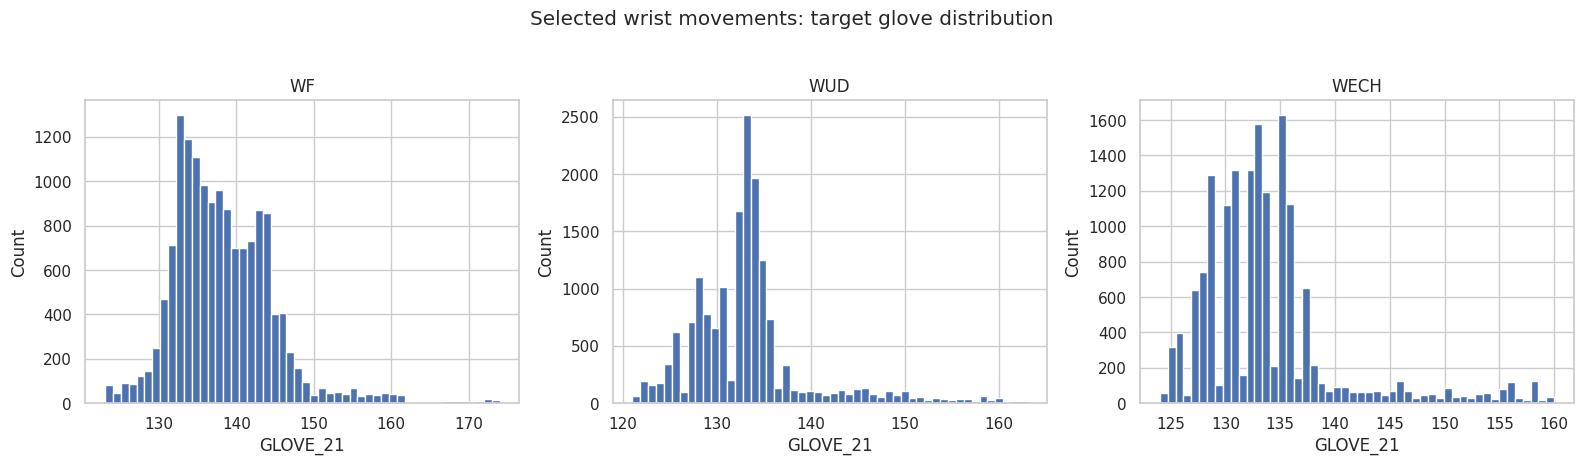

,Movement,count,mean,std,min,median,max
0,WECH,16116,133.8409,6.3561,124.0,133.0000,160.0
1,WF,15133,138.3897,6.5181,123.0,137.4548,174.0
2,WUD,16751,133.2418,6.4481,121.0,133.0000,163.0


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/selected_target_glove_statistics.csv


In [29]:
TARGET_GLOVE_NAME = (
    GLOVE_COLUMNS[
        TARGET_GLOVE_COLUMN
    ]
)

print(
    "Downstream target:",
    TARGET_GLOVE_NAME,
    (
        f"(zero-based column "
        f"{TARGET_GLOVE_COLUMN})"
    ),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        16,
        4.5,
    ),
)

for axis, (
    movement_label,
    movement_name,
) in zip(
    axes,
    SELECTED_MOVEMENTS.items(),
):
    values = (
        selected_eda_df.loc[
            selected_eda_df[
                "Movement_label"
            ]
            == movement_label,
            TARGET_GLOVE_NAME,
        ]
    )

    axis.hist(
        values,
        bins=50,
    )

    axis.set_title(
        movement_name
    )

    axis.set_xlabel(
        TARGET_GLOVE_NAME
    )

    axis.set_ylabel(
        "Count"
    )

fig.suptitle(
    "Selected wrist movements: target glove distribution",
    y=1.03,
)

plt.tight_layout()

save_figure(
    "selected_target_glove_distributions.png"
)

plt.show()

target_statistics = (
    selected_eda_df
    .groupby(
        "Movement"
    )[
        TARGET_GLOVE_NAME
    ]
    .agg(
        [
            "count",
            "mean",
            "std",
            "min",
            "median",
            "max",
        ]
    )
    .reset_index()
)

display(
    target_statistics.round(
        4
    )
)

save_table(
    target_statistics,
    "selected_target_glove_statistics.csv",
)

## L6. Selected-subset EMG activity by movement

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/selected_emg_rms_by_movement.png


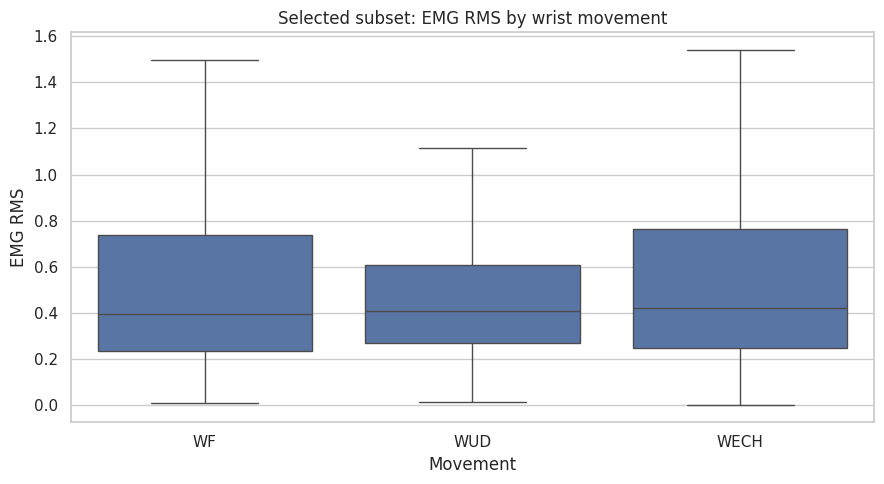

,mean,median,std
Movement,,,
WECH,0.59949,0.42101,0.51436
WF,0.55941,0.39615,0.47301
WUD,0.47714,0.40862,0.29003


In [30]:
plt.figure(
    figsize=(
        9,
        5,
    )
)

plot_selected = (
    selected_eda_df.sample(
        min(
            45_000,
            len(
                selected_eda_df
            ),
        ),
        random_state=RANDOM_STATE,
    )
)

sns.boxplot(
    data=plot_selected,
    x="Movement",
    y="EMG_RMS",
    order=[
        "WF",
        "WUD",
        "WECH",
    ],
    showfliers=False,
)

plt.title(
    "Selected subset: EMG RMS by wrist movement"
)

plt.xlabel(
    "Movement"
)

plt.ylabel(
    "EMG RMS"
)

plt.tight_layout()

save_figure(
    "selected_emg_rms_by_movement.png"
)

plt.show()

display(
    selected_eda_df
    .groupby(
        "Movement"
    )[
        "EMG_RMS"
    ]
    .agg(
        [
            "mean",
            "median",
            "std",
        ]
    )
    .round(
        5
    )
)

## L7. Selected-subset electrode × target correlation

,Electrode,Correlation_with_GLOVE_21
0,EMG_1,-0.1059
1,EMG_2,0.0322
2,EMG_3,0.0986
3,EMG_4,0.0572
4,EMG_5,0.0622
5,EMG_6,-0.0709
6,EMG_7,-0.2155
7,EMG_8,-0.2259
8,EMG_9,0.0051
9,EMG_10,-0.0736


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/selected_emg_target_correlation.png


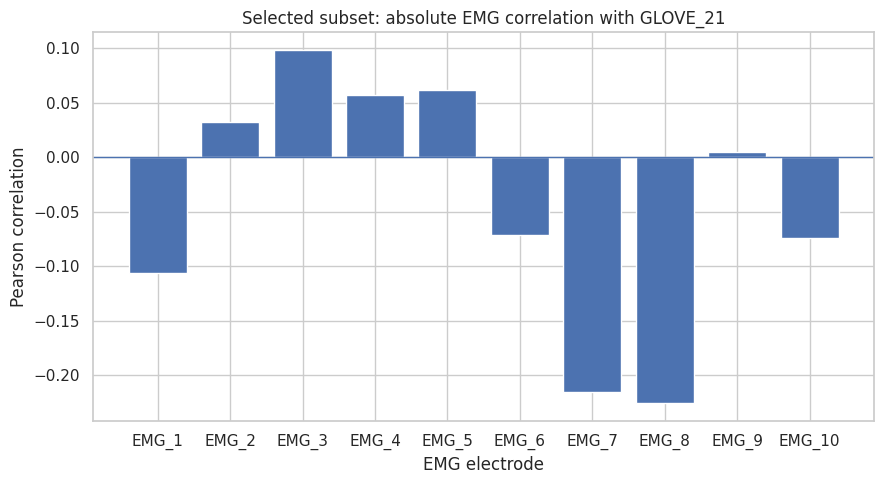

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/selected_emg_target_correlation.csv


In [31]:
selected_corr_source = (
    selected_eda_df.sample(
        min(
            40_000,
            len(
                selected_eda_df
            ),
        ),
        random_state=RANDOM_STATE,
    )
)

target_corr_rows = []

for electrode in EMG_COLUMNS:
    correlation_value = np.corrcoef(
        np.abs(
            selected_corr_source[
                electrode
            ].to_numpy()
        ),
        selected_corr_source[
            TARGET_GLOVE_NAME
        ].to_numpy(),
    )[
        0,
        1
    ]

    target_corr_rows.append(
        {
            "Electrode": (
                electrode
            ),
            (
                f"Correlation_with_"
                f"{TARGET_GLOVE_NAME}"
            ): float(
                correlation_value
            ),
        }
    )

selected_target_corr = (
    pd.DataFrame(
        target_corr_rows
    )
)

display(
    selected_target_corr.round(
        4
    )
)

plt.figure(
    figsize=(
        9,
        5,
    )
)

plt.bar(
    selected_target_corr[
        "Electrode"
    ],
    selected_target_corr[
        f"Correlation_with_{TARGET_GLOVE_NAME}"
    ],
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    (
        "Selected subset: absolute EMG correlation "
        f"with {TARGET_GLOVE_NAME}"
    )
)

plt.xlabel(
    "EMG electrode"
)

plt.ylabel(
    "Pearson correlation"
)

plt.tight_layout()

save_figure(
    "selected_emg_target_correlation.png"
)

plt.show()

save_table(
    selected_target_corr,
    "selected_emg_target_correlation.csv",
)

## L8. Temporal example for WF, WUD, and WECH

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/selected_temporal_examples.png


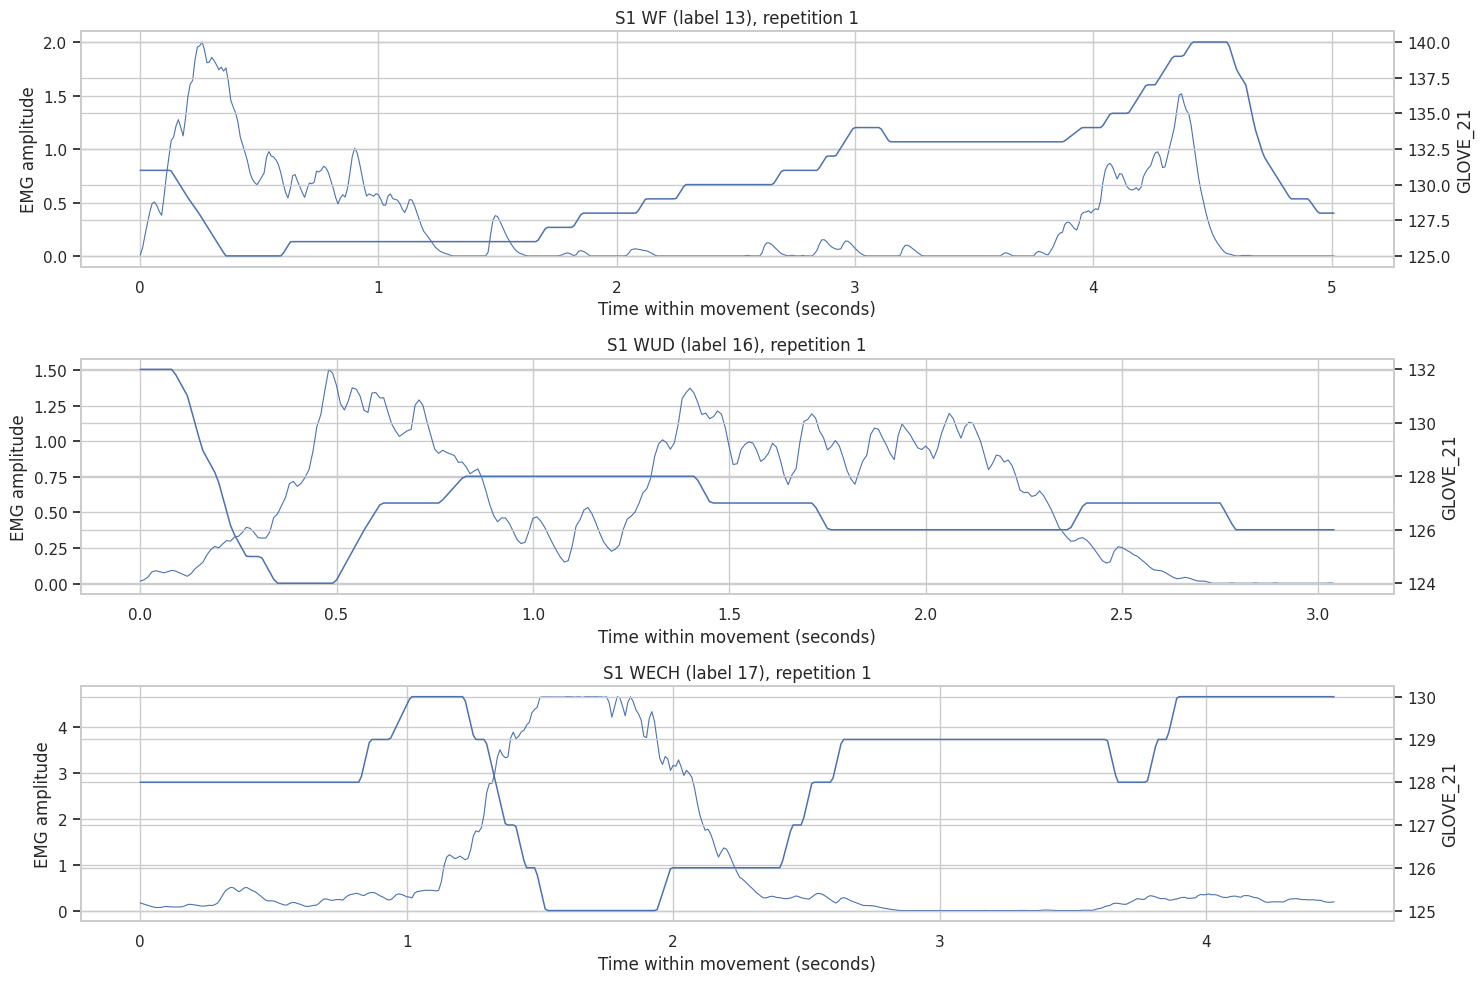

In [32]:
example_selected_path = next(
    path
    for path in selected_paths
    if parse_file_ids(
        path
    )[
        "subject"
    ] == 1
)

example_selected = load_db1(
    example_selected_path
)

labels = np.asarray(
    example_selected[
        "restimulus"
    ],
    dtype=np.int16,
)

repetitions = np.asarray(
    example_selected[
        "rerepetition"
    ],
    dtype=np.int16,
)

emg = np.asarray(
    example_selected[
        "emg"
    ]
)

glove = np.asarray(
    example_selected[
        "glove"
    ]
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(
        15,
        10,
    ),
)

for axis, (
    movement_label,
    movement_name,
) in zip(
    axes,
    SELECTED_MOVEMENTS.items(),
):
    indices = np.flatnonzero(
        (
            labels
            == movement_label
        )
        &
        (
            repetitions
            == 1
        )
    )

    runs = contiguous_runs(
        indices
    )

    if not runs:
        axis.set_title(
            (
                f"{movement_name}: "
                "repetition 1 not found"
            )
        )
        continue

    segment = max(
        runs,
        key=len,
    )

    local_time = (
        np.arange(
            len(
                segment
            )
        )
        / FS
    )

    selected_electrode = int(
        np.argmax(
            np.sqrt(
                np.mean(
                    emg[
                        segment
                    ] ** 2,
                    axis=0,
                )
            )
        )
    )

    axis.plot(
        local_time,
        emg[
            segment,
            selected_electrode,
        ],
        linewidth=0.8,
        label=(
            f"EMG E"
            f"{selected_electrode + 1}"
        ),
    )

    target_axis = (
        axis.twinx()
    )

    target_axis.plot(
        local_time,
        glove[
            segment,
            TARGET_GLOVE_COLUMN,
        ],
        linewidth=1.1,
        label=TARGET_GLOVE_NAME,
    )

    axis.set_title(
        (
            f"S1 {movement_name} "
            f"(label {movement_label}), repetition 1"
        )
    )

    axis.set_xlabel(
        "Time within movement (seconds)"
    )

    axis.set_ylabel(
        "EMG amplitude"
    )

    target_axis.set_ylabel(
        TARGET_GLOVE_NAME
    )

plt.tight_layout()

save_figure(
    "selected_temporal_examples.png"
)

plt.show()

# M. Final EDA conclusion

In [33]:
selected_total_samples = int(
    selected_inventory[
        "Samples"
    ].sum()
)

selected_total_duration = float(
    selected_inventory[
        "Duration_min"
    ].sum()
)

conclusion_df = pd.DataFrame(
    {
        "Scope": [
            "Full DB1 EDA",
            "Full DB1 signals",
            "Full DB1 labels",
            "Downstream subset",
            "Downstream movements",
            "Downstream target",
        ],
        "Conclusion": [
            (
                f"EDA covered {N_SUBJECTS} subjects "
                f"and Exercises {EXERCISES}."
            ),
            (
                f"All audited files contain "
                f"{N_EMG} EMG and {N_GLOVE} glove channels "
                "with synchronized sample lengths."
            ),
            (
                f"{len(active_labels)} active movement labels "
                "were discovered directly from restimulus."
            ),
            (
                f"Later regression uses Subjects 1–8 "
                f"from Exercise {SELECTED_EXERCISE}, "
                f"with {selected_total_samples:,} selected "
                f"active samples "
                f"({selected_total_duration:.2f} min)."
            ),
            (
                "WF (13), WUD (16), and WECH (17) "
                "are the three selected wrist movements."
            ),
            (
                f"{TARGET_GLOVE_NAME} "
                f"(zero-based glove column "
                f"{TARGET_GLOVE_COLUMN}) "
                "is documented separately for the "
                "continuous wrist-angle experiment."
            ),
        ],
    }
)

display(
    conclusion_df
)

save_table(
    conclusion_df,
    "eda_final_conclusion.csv",
)

,Scope,Conclusion
0,Full DB1 EDA,"EDA covered 27 subjects and Exercises (1, 2, 3)."
1,Full DB1 signals,All audited files contain 10 EMG and 22 glove ...
2,Full DB1 labels,23 active movement labels were discovered dire...
3,Downstream subset,Later regression uses Subjects 1–8 from Exerci...
4,Downstream movements,"WF (13), WUD (16), and WECH (17) are the three..."
5,Downstream target,GLOVE_21 (zero-based glove column 20) is docum...


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/eda_final_conclusion.csv


## Report-ready EDA description

You can use this wording in the report after running the notebook and inserting the actual generated values:

> Exploratory data analysis was first conducted on the complete preprocessed NinaPro DB1 dataset rather than only on the subset used for modeling. The analysis covered all 27 subjects and all three exercises, examining the 10-channel sEMG signals, 22-channel glove measurements, movement labels, repetitions, recording durations, signal integrity, channel distributions, inter-channel correlations, and between-subject variability. A separate focused analysis was then performed for the downstream wrist-angle regression subset consisting of the first eight subjects from Exercise 2 and three wrist-related movements: wrist flexion (label 13), wrist ulnar deviation (label 16), and wrist extension with closed hand (label 17). This separation ensures that dataset-level characteristics are reported using the complete DB1 corpus while the experimental subset used in later model development is transparently documented.

## N. Generated EDA files

In [34]:
print(
    "Tables directory:",
    TABLE_DIR.resolve(),
)

print(
    "Figures directory:",
    FIGURE_DIR.resolve(),
)

print(
    "\nGenerated tables:"
)

for path in sorted(
    TABLE_DIR.glob(
        "*.csv"
    )
):
    print(
        " -",
        path.name,
    )

print(
    "\nGenerated figures:"
)

for path in sorted(
    FIGURE_DIR.glob(
        "*.png"
    )
):
    print(
        " -",
        path.name,
    )

Tables directory: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables
Figures directory: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures

Generated tables:
 - channel_quality.csv
 - eda_final_conclusion.csv
 - exercise_summary.csv
 - full_dataset_summary.csv
 - full_eda_findings.csv
 - full_emg_descriptive_statistics.csv
 - full_file_inventory.csv
 - full_glove_descriptive_statistics.csv
 - movement_label_summary.csv
 - movement_labels_by_exercise.csv
 - repetition_coverage.csv
 - sample_file_variables.csv
 - selected_8_subject_3_movement_inventory.csv
 - selected_emg_target_correlation.csv
 - selected_subset_movement_summary.csv
 - selected_subset_repetition_coverage.csv
 - selected_target_glove_statistics.csv
 - subject_summary.csv

Generated figures:
 - active_emg_rms_by_exercise.png
 - all_movement_sample_counts.png
 - between_subject_variability.png
 - emg_channel_correlation.png
 - emg_glove_correlation.png
 - exercise_samples_duration.png
 - full_db1_emg_pca.png
 - 

# O. Additional Signal-Level EDA Figures

The following figures are added because signal-level visualization is important for the NinaPro DB1 EDA.

They complement the previous:

- distributions;
- correlations;
- PCA;
- subject/exercise summaries.

The new figures specifically show:

1. **synchronization** between EMG, glove, and movement labels;
2. **repetition-to-repetition variability** in EMG;
3. **repetition-to-repetition variability** in the wrist target;
4. **electrode activity differences** across WF, WUD, and WECH.

No model training is performed in this section.

## O1. Helper functions for signal smoothing and repetition extraction

In [35]:
def moving_average(
    values,
    window=15,
):
    values = np.asarray(
        values,
        dtype=np.float32,
    )

    if window <= 1:
        return values

    if len(values) < window:
        return values

    kernel = np.ones(
        window,
        dtype=np.float32,
    ) / float(window)

    return np.convolve(
        values,
        kernel,
        mode="same",
    )


def get_repetition_segment(
    labels,
    repetitions,
    movement_label,
    repetition_number,
):
    indices = np.flatnonzero(
        (
            labels
            == movement_label
        )
        &
        (
            repetitions
            == repetition_number
        )
    )

    runs = contiguous_runs(
        indices
    )

    if not runs:
        return np.array(
            [],
            dtype=np.int64,
        )

    # Use the longest contiguous run in case
    # the label is fragmented by relabeling.
    return max(
        runs,
        key=len,
    )


def strongest_electrode_for_movement(
    emg,
    labels,
    movement_label,
):
    mask = (
        labels
        == movement_label
    )

    if not np.any(mask):
        return 0

    rms = np.sqrt(
        np.mean(
            emg[
                mask
            ] ** 2,
            axis=0,
        )
    )

    return int(
        np.argmax(
            rms
        )
    )

## O2. Synchronized EMG + glove + movement-label plots

For each exercise, one representative Subject-1 file is shown using a common time axis.

### Top panel
Four representative EMG electrodes:

```text
E1, E4, E7, E10
```

### Middle panel
Four representative glove sensors:

```text
G1, G8, G15, G22
```

### Bottom panel
The relabeled movement signal (`restimulus`).

This figure visually verifies that the physiological and kinematic signals are synchronized in time.

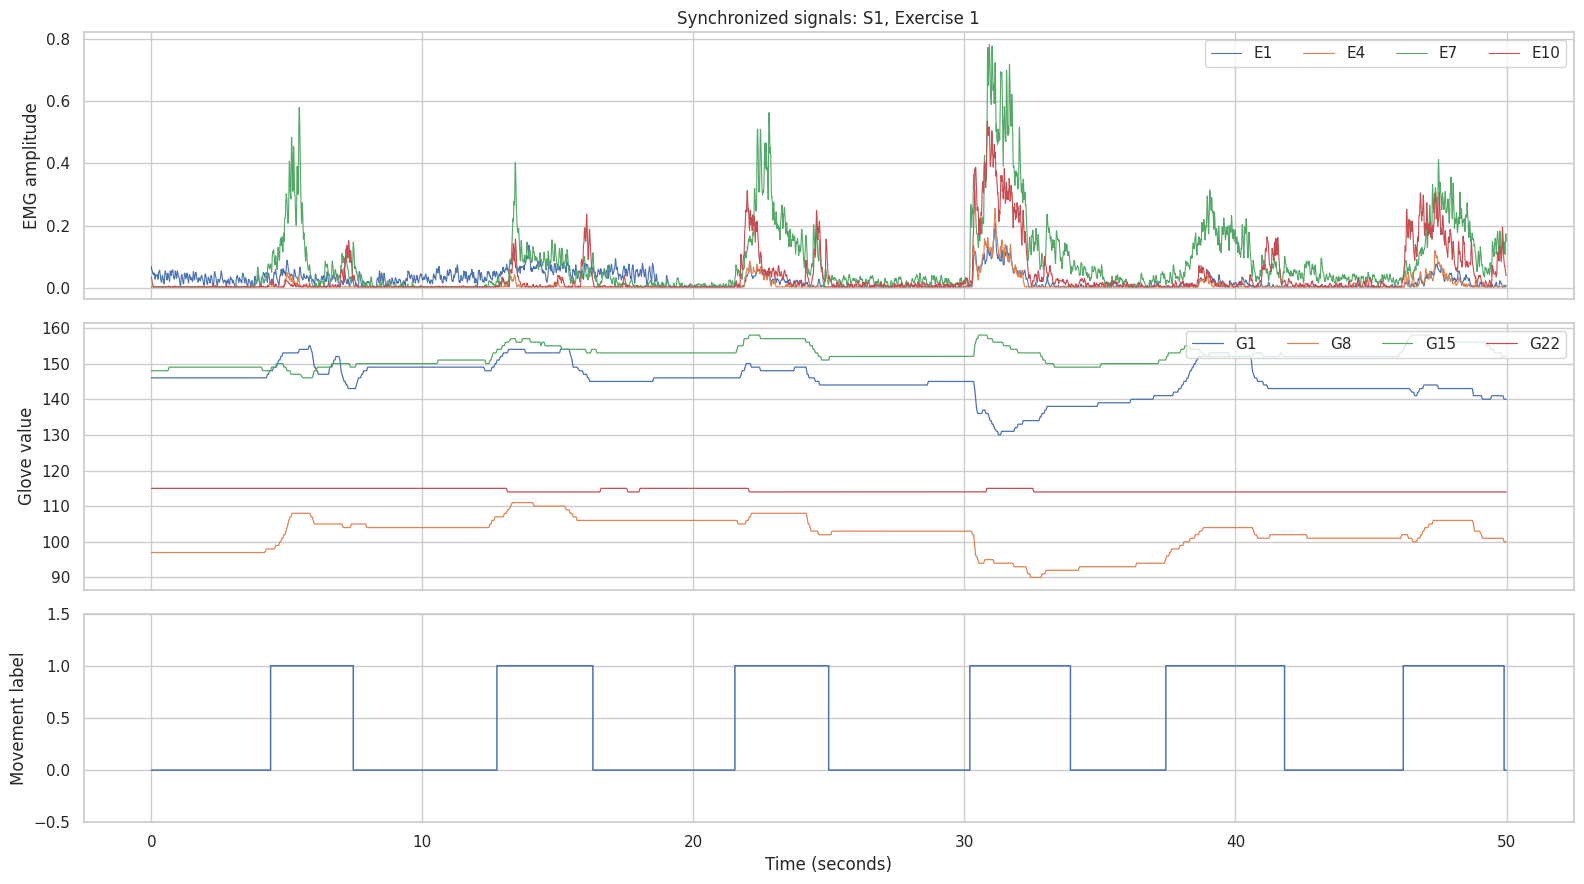

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/synchronized_S1_E1.png


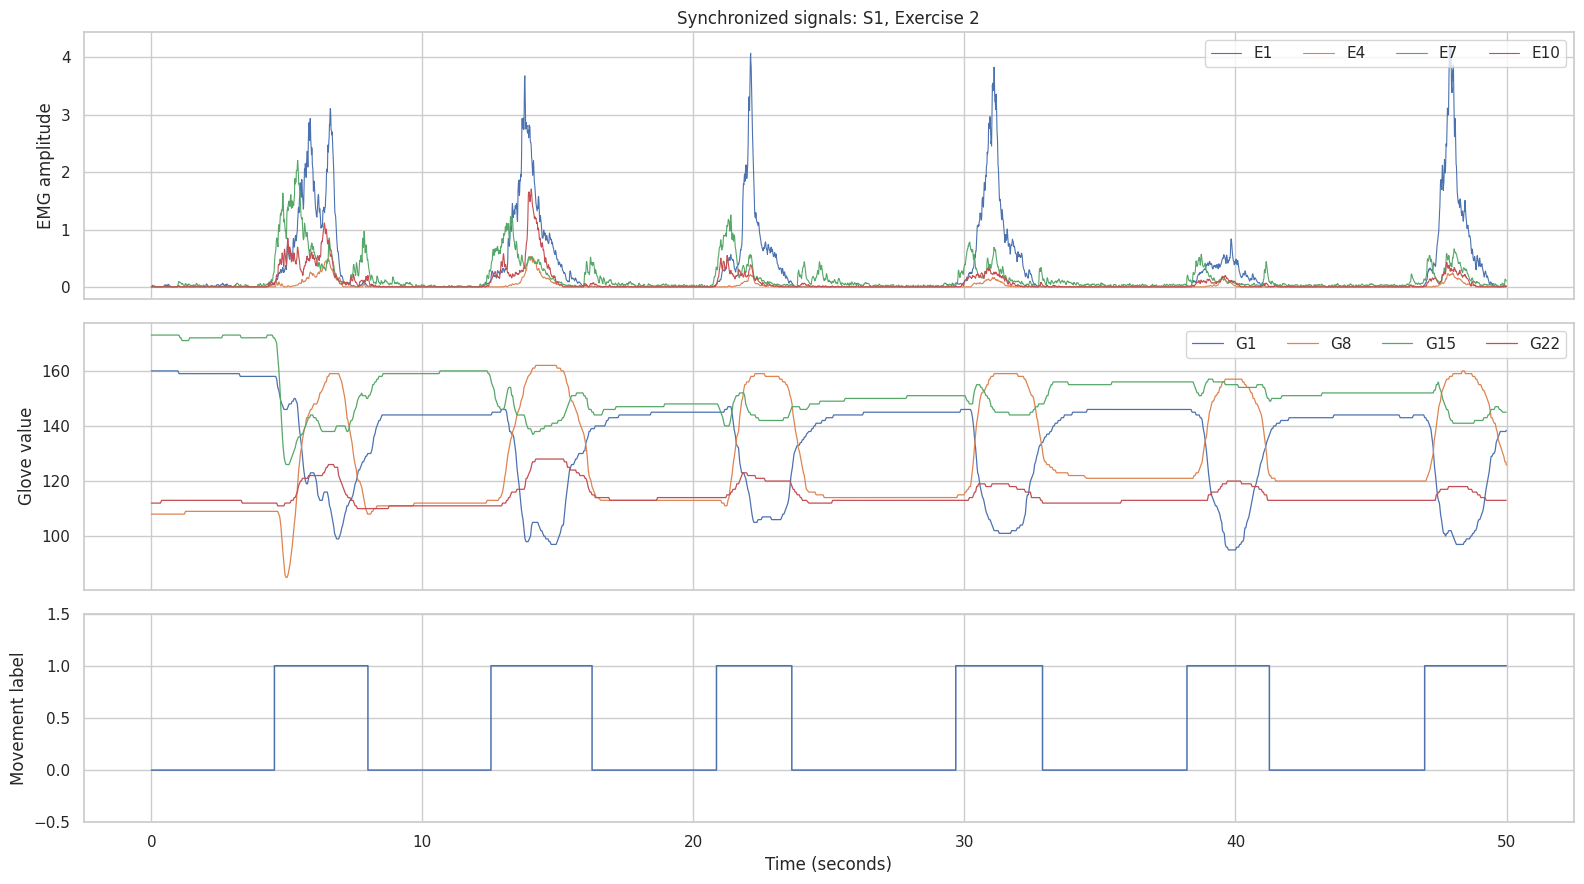

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/synchronized_S1_E2.png


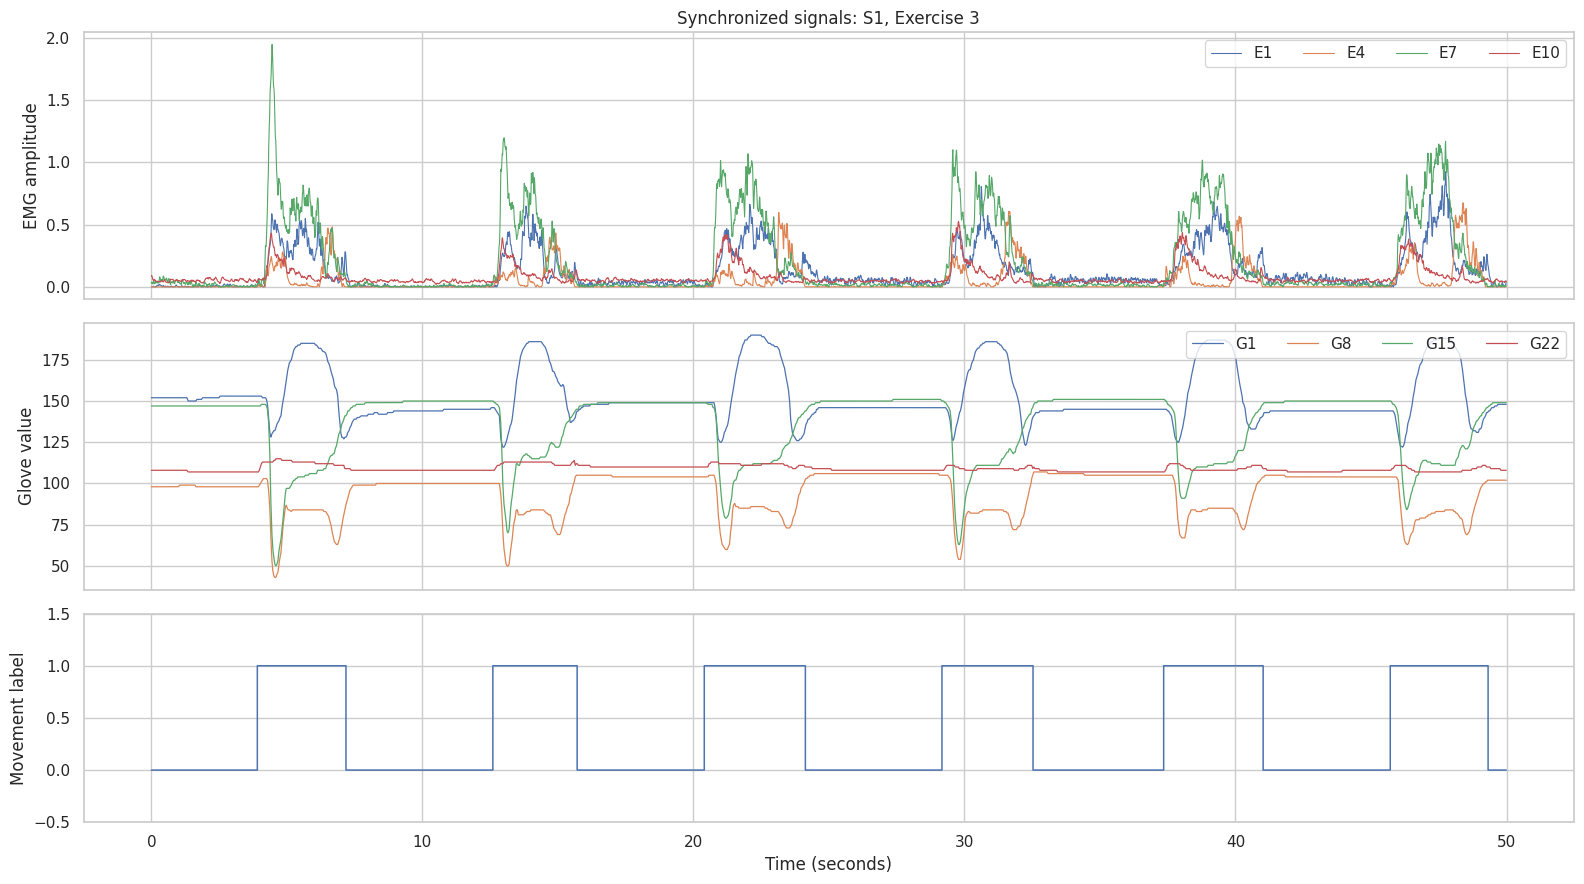

Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/synchronized_S1_E3.png


In [36]:
SYNC_EMG_CHANNELS = [
    0,  # E1
    3,  # E4
    6,  # E7
    9,  # E10
]

SYNC_GLOVE_CHANNELS = [
    0,   # G1
    7,   # G8
    14,  # G15
    21,  # G22
]

SYNC_SECONDS = 50


def plot_synchronized_signals(
    subject,
    exercise,
    seconds=SYNC_SECONDS,
):
    file_path = next(
        path
        for path in mat_files
        if (
            parse_file_ids(
                path
            )["subject"]
            == subject
            and parse_file_ids(
                path
            )["exercise"]
            == exercise
        )
    )

    data = load_db1(
        file_path
    )

    emg = np.asarray(
        data["emg"]
    )

    glove = np.asarray(
        data["glove"]
    )

    labels = np.asarray(
        data["restimulus"],
        dtype=np.int16,
    )

    stop = min(
        len(emg),
        int(
            seconds
            * FS
        ),
    )

    time_axis = (
        np.arange(
            stop
        )
        / FS
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(
            16,
            9,
        ),
        sharex=True,
        gridspec_kw={
            "height_ratios": [
                1.15,
                1.15,
                0.9,
            ]
        },
    )

    # --------------------------------------------------
    # EMG
    # --------------------------------------------------
    for channel in (
        SYNC_EMG_CHANNELS
    ):
        axes[0].plot(
            time_axis,
            emg[
                :stop,
                channel,
            ],
            linewidth=0.8,
            label=(
                f"E{channel + 1}"
            ),
        )

    axes[0].set_ylabel(
        "EMG amplitude"
    )

    axes[0].set_title(
        (
            f"Synchronized signals: "
            f"S{subject}, Exercise {exercise}"
        )
    )

    axes[0].legend(
        ncol=4,
        loc="upper right",
    )

    # --------------------------------------------------
    # Glove
    # --------------------------------------------------
    for channel in (
        SYNC_GLOVE_CHANNELS
    ):
        axes[1].plot(
            time_axis,
            glove[
                :stop,
                channel,
            ],
            linewidth=0.9,
            label=(
                f"G{channel + 1}"
            ),
        )

    axes[1].set_ylabel(
        "Glove value"
    )

    axes[1].legend(
        ncol=4,
        loc="upper right",
    )

    # --------------------------------------------------
    # Movement label
    # --------------------------------------------------
    axes[2].step(
        time_axis,
        labels[
            :stop
        ],
        where="post",
        linewidth=1.1,
    )

    axes[2].set_ylabel(
        "Movement label"
    )

    axes[2].set_xlabel(
        "Time (seconds)"
    )

    axes[2].set_ylim(
        labels[
            :stop
        ].min()
        - 0.5,
        labels[
            :stop
        ].max()
        + 0.5,
    )

    plt.tight_layout()

    save_path = (
        FIGURE_DIR
        / (
            f"synchronized_"
            f"S{subject}_E{exercise}.png"
        )
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        save_path,
    )


for exercise in EXERCISES:
    plot_synchronized_signals(
        subject=1,
        exercise=exercise,
        seconds=SYNC_SECONDS,
    )

## O3. Repetition-overlaid EMG signal for WF, WUD, and WECH

This reproduces the useful repetition-style signal visualization.

For each movement:

1. Subject 1 is used as the representative subject.
2. The electrode with the highest RMS activity for that movement is selected automatically.
3. Repetitions 1–10 are extracted separately.
4. The absolute EMG signal is smoothed.
5. All repetitions are plotted on the same **time-within-repetition** axis.

This shows how strongly the sEMG waveform varies across repeated executions of the same movement.

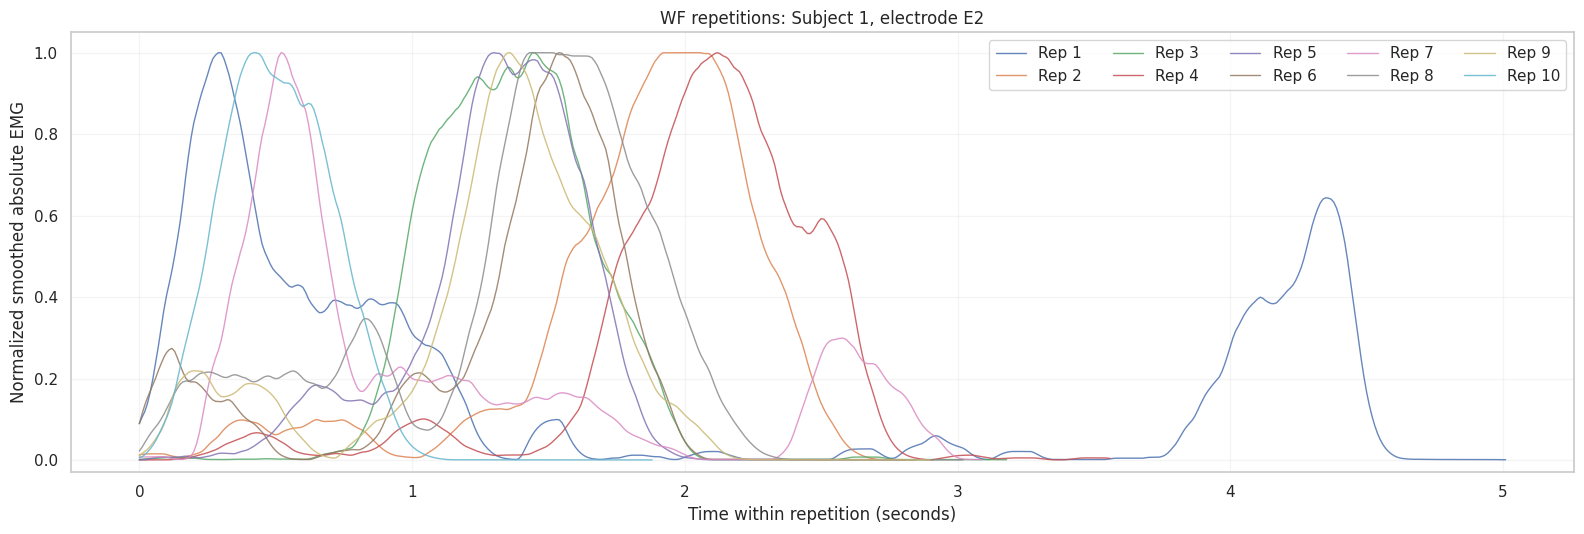

,Movement,Movement_label,Subject,Electrode,Repetition,Duration_seconds,Mean_absolute_EMG,RMS_EMG,Peak_smoothed_absolute_EMG
0,WF,13,1,E2,1,5.02,0.31734,0.55970,1.82616
1,WF,13,1,E2,2,2.85,1.31906,2.07051,4.65851
2,WF,13,1,E2,3,3.19,0.45621,0.83775,1.97315
3,WF,13,1,E2,4,3.57,0.98388,1.76430,4.60448
4,WF,13,1,E2,5,2.80,0.65518,1.14388,2.77685
5,WF,13,1,E2,6,2.82,0.39905,0.67942,1.86084
6,WF,13,1,E2,7,3.10,0.28077,0.44687,1.41456
7,WF,13,1,E2,8,3.03,1.36549,2.04976,4.65836
8,WF,13,1,E2,9,2.91,0.93952,1.52647,4.12647
9,WF,13,1,E2,10,1.89,1.31246,2.16987,4.64127


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/repetition_overlay_EMG_S1_WF.png
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/repetition_summary_S1_WF.csv


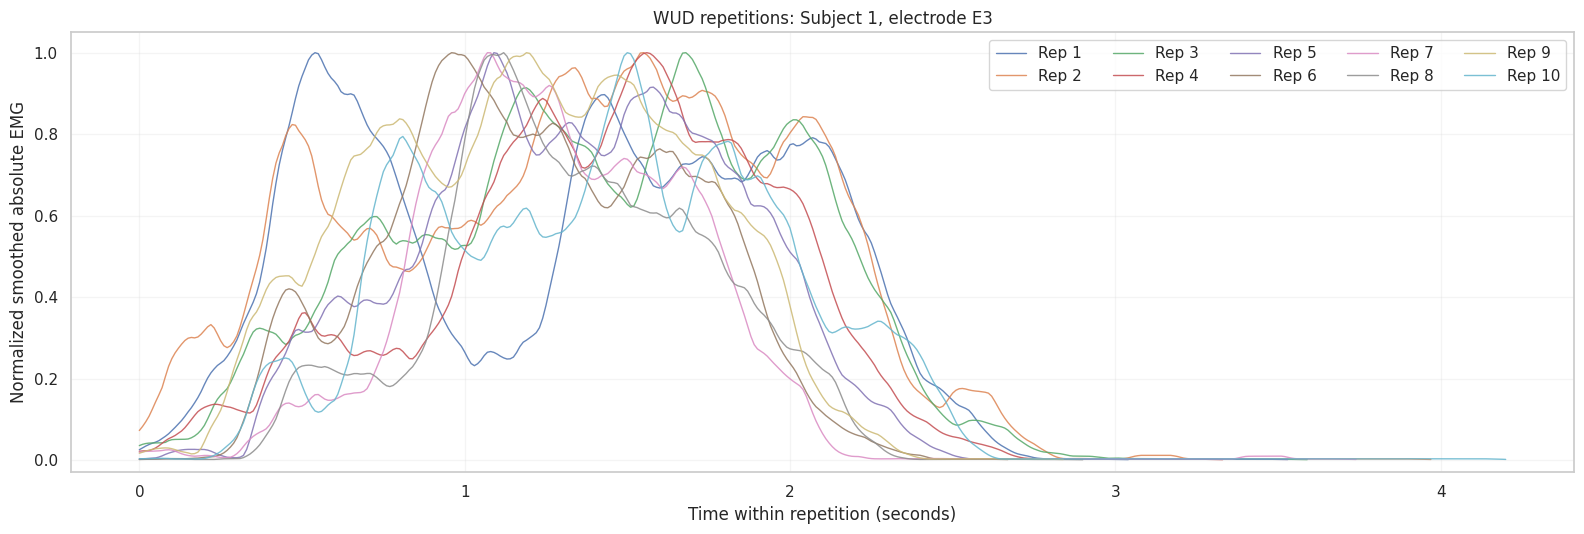

,Movement,Movement_label,Subject,Electrode,Repetition,Duration_seconds,Mean_absolute_EMG,RMS_EMG,Peak_smoothed_absolute_EMG
0,WUD,16,1,E3,1,3.05,0.60691,0.74831,1.33171
1,WUD,16,1,E3,2,3.98,0.34926,0.47061,0.87825
2,WUD,16,1,E3,3,3.60,0.47034,0.62654,1.23161
3,WUD,16,1,E3,4,3.34,0.46954,0.64816,1.34505
4,WUD,16,1,E3,5,3.54,0.36830,0.53880,1.12044
5,WUD,16,1,E3,6,2.68,0.46901,0.61589,1.15722
6,WUD,16,1,E3,7,3.75,0.25054,0.42291,1.00357
7,WUD,16,1,E3,8,2.91,0.47121,0.68500,1.58170
8,WUD,16,1,E3,9,2.85,0.41865,0.53876,0.91927
9,WUD,16,1,E3,10,4.21,0.25465,0.39181,0.94840


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/repetition_overlay_EMG_S1_WUD.png
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/repetition_summary_S1_WUD.csv


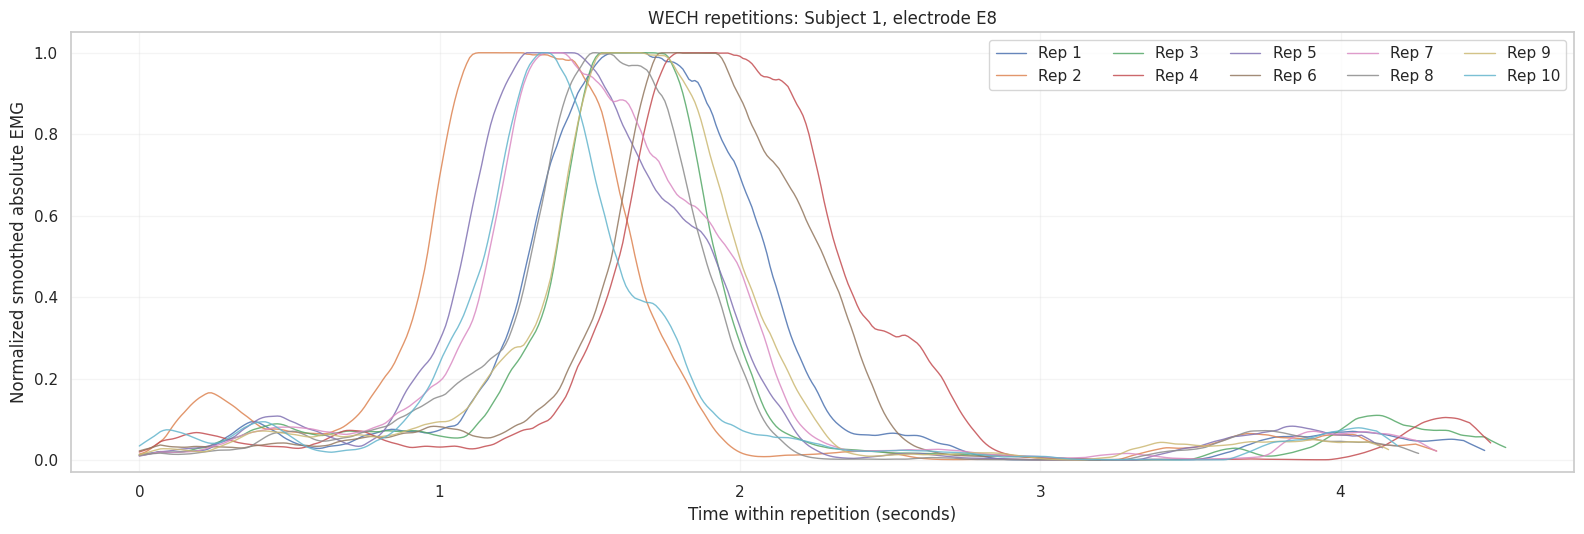

,Movement,Movement_label,Subject,Electrode,Repetition,Duration_seconds,Mean_absolute_EMG,RMS_EMG,Peak_smoothed_absolute_EMG
0,WECH,17,1,E8,1,4.49,0.96003,1.77187,4.65949
1,WECH,17,1,E8,2,4.33,0.93592,1.76980,4.65966
2,WECH,17,1,E8,3,4.56,0.74326,1.51490,4.65950
3,WECH,17,1,E8,4,4.51,0.96509,1.77509,4.65999
4,WECH,17,1,E8,5,4.15,1.02111,1.81553,4.66063
5,WECH,17,1,E8,6,3.21,1.15129,1.94346,4.65917
6,WECH,17,1,E8,7,4.33,0.95804,1.72489,4.65933
7,WECH,17,1,E8,8,4.27,0.79813,1.57622,4.65298
8,WECH,17,1,E8,9,4.17,0.89043,1.67517,4.66079
9,WECH,17,1,E8,10,4.20,0.71601,1.39137,4.65804


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/repetition_overlay_EMG_S1_WECH.png
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/repetition_summary_S1_WECH.csv


In [37]:
REPETITION_PLOT_SUBJECT = 1
SMOOTHING_WINDOW = 15


def plot_movement_repetition_emg(
    subject,
    movement_label,
    smoothing_window=SMOOTHING_WINDOW,
):
    movement_name = (
        SELECTED_MOVEMENTS[
            movement_label
        ]
    )

    file_path = next(
        path
        for path in selected_paths
        if parse_file_ids(
            path
        )["subject"]
        == subject
    )

    data = load_db1(
        file_path
    )

    emg = np.asarray(
        data["emg"]
    )

    labels = np.asarray(
        data["restimulus"],
        dtype=np.int16,
    )

    repetitions = np.asarray(
        data["rerepetition"],
        dtype=np.int16,
    )

    electrode = (
        strongest_electrode_for_movement(
            emg,
            labels,
            movement_label,
        )
    )

    figure = plt.figure(
        figsize=(
            16,
            5.5,
        )
    )

    summary_rows = []

    for repetition_number in range(
        1,
        11,
    ):
        segment = (
            get_repetition_segment(
                labels,
                repetitions,
                movement_label,
                repetition_number,
            )
        )

        if len(
            segment
        ) == 0:
            continue

        signal = np.abs(
            emg[
                segment,
                electrode,
            ]
        )

        smoothed = moving_average(
            signal,
            window=smoothing_window,
        )

        # Normalize only for this visualization,
        # so repeated shapes can be compared easily.
        local_max = float(
            np.max(
                smoothed
            )
        )

        if local_max > 1e-8:
            displayed_signal = (
                smoothed
                / local_max
            )
        else:
            displayed_signal = (
                smoothed
            )

        time_axis = (
            np.arange(
                len(
                    displayed_signal
                )
            )
            / FS
        )

        plt.plot(
            time_axis,
            displayed_signal,
            linewidth=1.0,
            alpha=0.85,
            label=(
                f"Rep {repetition_number}"
            ),
        )

        summary_rows.append(
            {
                "Movement": (
                    movement_name
                ),
                "Movement_label": (
                    movement_label
                ),
                "Subject": (
                    subject
                ),
                "Electrode": (
                    f"E{electrode + 1}"
                ),
                "Repetition": (
                    repetition_number
                ),
                "Duration_seconds": (
                    len(
                        segment
                    )
                    / FS
                ),
                "Mean_absolute_EMG": (
                    float(
                        np.mean(
                            signal
                        )
                    )
                ),
                "RMS_EMG": (
                    float(
                        np.sqrt(
                            np.mean(
                                signal ** 2
                            )
                        )
                    )
                ),
                "Peak_smoothed_absolute_EMG": (
                    local_max
                ),
            }
        )

    plt.title(
        (
            f"{movement_name} repetitions: "
            f"Subject {subject}, "
            f"electrode E{electrode + 1}"
        )
    )

    plt.xlabel(
        "Time within repetition (seconds)"
    )

    plt.ylabel(
        "Normalized smoothed absolute EMG"
    )

    plt.ylim(
        -0.03,
        1.05,
    )

    plt.legend(
        ncol=5,
        loc="upper right",
    )

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            f"repetition_overlay_EMG_"
            f"S{subject}_{movement_name}.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    summary_df = pd.DataFrame(
        summary_rows
    )

    display(
        summary_df.round(
            5
        )
    )

    summary_path = (
        TABLE_DIR
        / (
            f"repetition_summary_"
            f"S{subject}_{movement_name}.csv"
        )
    )

    summary_df.to_csv(
        summary_path,
        index=False,
    )

    print(
        "Saved:",
        figure_path,
    )

    print(
        "Saved:",
        summary_path,
    )

    return (
        electrode,
        summary_df,
    )


repetition_emg_outputs = {}

for movement_label in (
    SELECTED_MOVEMENTS
):
    repetition_emg_outputs[
        movement_label
    ] = (
        plot_movement_repetition_emg(
            subject=(
                REPETITION_PLOT_SUBJECT
            ),
            movement_label=(
                movement_label
            ),
        )
    )

## O4. Target-glove trajectory across repetitions

For the same three wrist movements, the downstream regression target (`GLOVE_21`, zero-based column 20) is plotted for repetitions 1–10.

This is useful because the model predicts a continuous wrist-related glove signal, so the EDA should show how the target trajectory changes across repeated trials.

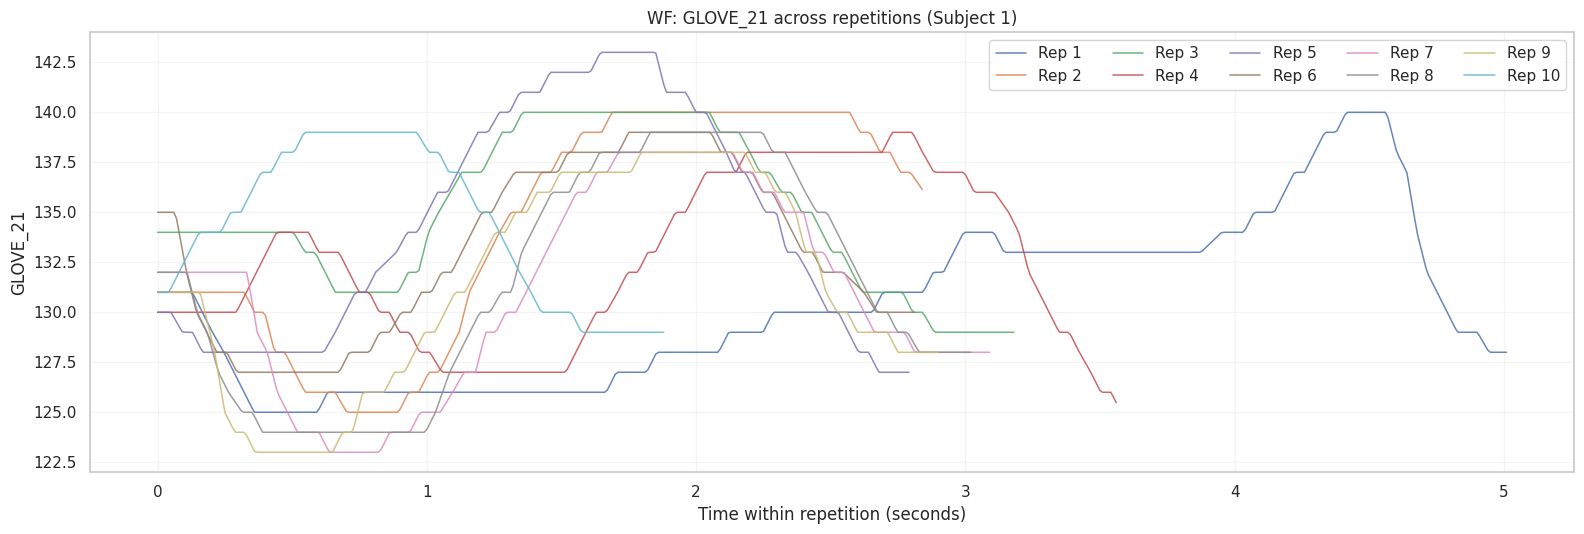

,Subject,Movement,Movement_label,Repetition,Duration_seconds,Target_mean,Target_std,Target_min,Target_max,Target_range
0,1,WF,13,1,5.02,130.3345,4.0053,125.0000,140.0,15.0000
1,1,WF,13,2,2.85,134.2139,5.6319,125.0000,140.0,15.0000
2,1,WF,13,3,3.19,134.8835,3.8013,129.0000,140.0,11.0000
3,1,WF,13,4,3.57,132.5256,4.1157,125.4858,139.0,13.5142
4,1,WF,13,5,2.80,134.4195,5.6196,127.0000,143.0,16.0000
5,1,WF,13,6,2.82,133.0868,4.2504,127.0000,139.0,12.0000
6,1,WF,13,7,3.10,130.8719,4.8926,123.0000,138.0,15.0000
7,1,WF,13,8,3.03,131.2800,5.5731,124.0000,139.0,15.0000
8,1,WF,13,9,2.91,131.3021,5.1673,123.0000,138.0,15.0000
9,1,WF,13,10,1.89,134.4790,3.8019,129.0000,139.0,10.0000


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/target_repetition_overlay_S1_WF.png
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/target_repetition_summary_S1_WF.csv


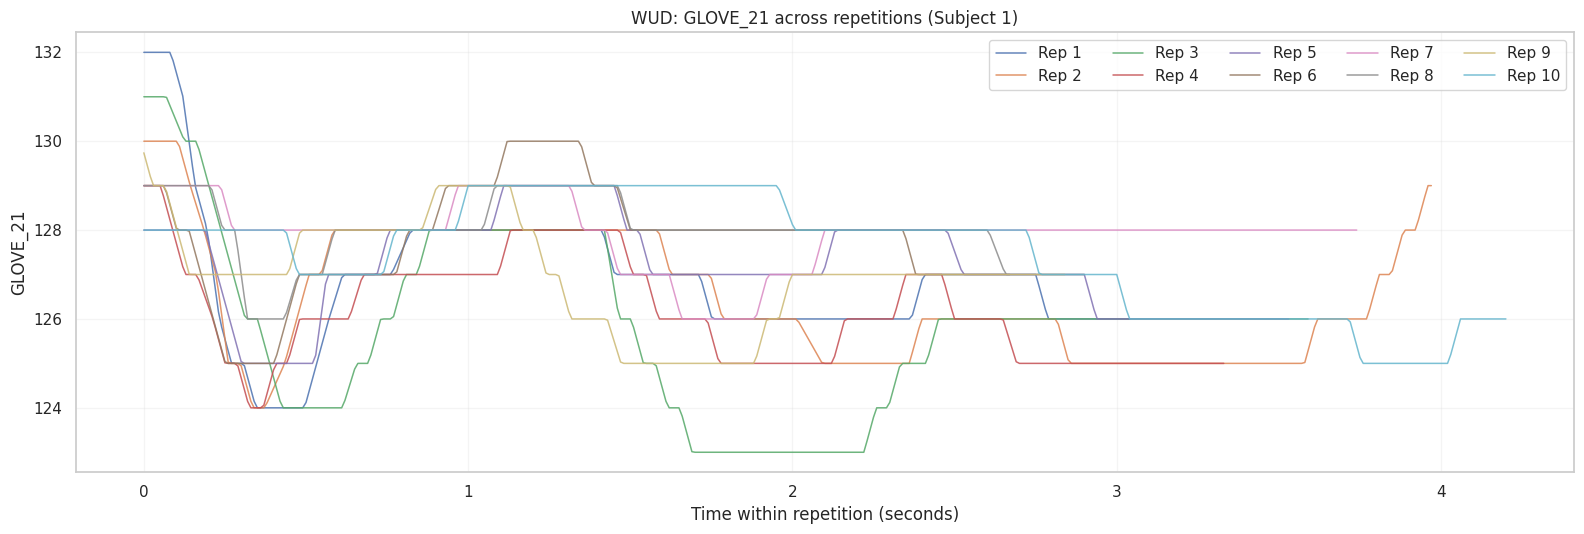

,Subject,Movement,Movement_label,Repetition,Duration_seconds,Target_mean,Target_std,Target_min,Target_max,Target_range
0,1,WUD,16,1,3.05,126.8828,1.5222,124.0,132.0000,8.0000
1,1,WUD,16,2,3.98,126.5049,1.4275,124.0,130.0000,6.0000
2,1,WUD,16,3,3.60,125.8744,1.9412,123.0,131.0000,8.0000
3,1,WUD,16,4,3.34,126.1376,1.1550,124.0,129.0000,5.0000
4,1,WUD,16,5,3.54,127.1724,1.0705,125.0,129.0000,4.0000
5,1,WUD,16,6,2.68,127.8181,1.2164,125.0,130.0000,5.0000
6,1,WUD,16,7,3.75,127.9321,0.7331,126.0,129.0000,3.0000
7,1,WUD,16,8,2.91,127.9831,0.7391,126.0,129.0000,3.0000
8,1,WUD,16,9,2.85,127.0429,1.1822,125.0,129.7381,4.7381
9,1,WUD,16,10,4.21,127.4647,1.2506,125.0,129.0000,4.0000


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/target_repetition_overlay_S1_WUD.png
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/target_repetition_summary_S1_WUD.csv


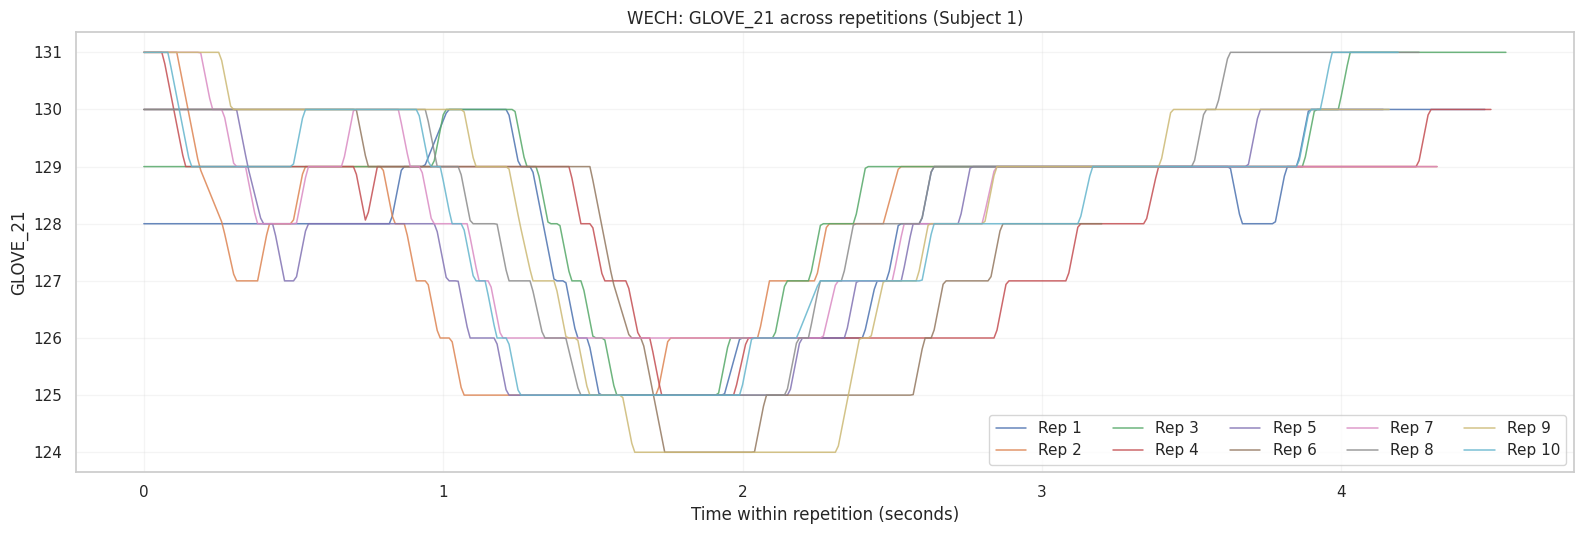

,Subject,Movement,Movement_label,Repetition,Duration_seconds,Target_mean,Target_std,Target_min,Target_max,Target_range
0,1,WECH,17,1,4.49,128.1008,1.5735,125.0,130.0,5.0
1,1,WECH,17,2,4.33,127.8574,1.6363,125.0,131.0,6.0
2,1,WECH,17,3,4.56,128.6850,1.5866,125.0,131.0,6.0
3,1,WECH,17,4,4.51,127.9747,1.5364,125.0,131.0,6.0
4,1,WECH,17,5,4.15,127.6735,1.8358,125.0,130.0,5.0
5,1,WECH,17,6,3.21,127.5788,2.1215,124.0,130.0,6.0
6,1,WECH,17,7,4.33,128.1006,1.4756,126.0,131.0,5.0
7,1,WECH,17,8,4.27,128.5350,2.0214,125.0,131.0,6.0
8,1,WECH,17,9,4.17,128.1673,2.3661,124.0,131.0,7.0
9,1,WECH,17,10,4.20,127.9819,1.8870,125.0,131.0,6.0


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/target_repetition_overlay_S1_WECH.png
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/target_repetition_summary_S1_WECH.csv


In [38]:
def plot_target_repetition_overlay(
    subject,
    movement_label,
):
    movement_name = (
        SELECTED_MOVEMENTS[
            movement_label
        ]
    )

    file_path = next(
        path
        for path in selected_paths
        if parse_file_ids(
            path
        )["subject"]
        == subject
    )

    data = load_db1(
        file_path
    )

    glove = np.asarray(
        data["glove"]
    )

    labels = np.asarray(
        data["restimulus"],
        dtype=np.int16,
    )

    repetitions = np.asarray(
        data["rerepetition"],
        dtype=np.int16,
    )

    plt.figure(
        figsize=(
            16,
            5.5,
        )
    )

    rows = []

    for repetition_number in range(
        1,
        11,
    ):
        segment = (
            get_repetition_segment(
                labels,
                repetitions,
                movement_label,
                repetition_number,
            )
        )

        if len(
            segment
        ) == 0:
            continue

        target = glove[
            segment,
            TARGET_GLOVE_COLUMN,
        ]

        time_axis = (
            np.arange(
                len(
                    target
                )
            )
            / FS
        )

        plt.plot(
            time_axis,
            target,
            linewidth=1.1,
            alpha=0.85,
            label=(
                f"Rep {repetition_number}"
            ),
        )

        rows.append(
            {
                "Subject": subject,
                "Movement": (
                    movement_name
                ),
                "Movement_label": (
                    movement_label
                ),
                "Repetition": (
                    repetition_number
                ),
                "Duration_seconds": (
                    len(
                        segment
                    )
                    / FS
                ),
                "Target_mean": (
                    float(
                        np.mean(
                            target
                        )
                    )
                ),
                "Target_std": (
                    float(
                        np.std(
                            target
                        )
                    )
                ),
                "Target_min": (
                    float(
                        np.min(
                            target
                        )
                    )
                ),
                "Target_max": (
                    float(
                        np.max(
                            target
                        )
                    )
                ),
                "Target_range": (
                    float(
                        np.ptp(
                            target
                        )
                    )
                ),
            }
        )

    plt.title(
        (
            f"{movement_name}: "
            f"{TARGET_GLOVE_NAME} "
            f"across repetitions "
            f"(Subject {subject})"
        )
    )

    plt.xlabel(
        "Time within repetition (seconds)"
    )

    plt.ylabel(
        TARGET_GLOVE_NAME
    )

    plt.legend(
        ncol=5,
        loc="best",
    )

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            f"target_repetition_overlay_"
            f"S{subject}_{movement_name}.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    target_rep_df = (
        pd.DataFrame(
            rows
        )
    )

    display(
        target_rep_df.round(
            4
        )
    )

    table_path = (
        TABLE_DIR
        / (
            f"target_repetition_summary_"
            f"S{subject}_{movement_name}.csv"
        )
    )

    target_rep_df.to_csv(
        table_path,
        index=False,
    )

    print(
        "Saved:",
        figure_path,
    )

    print(
        "Saved:",
        table_path,
    )


for movement_label in (
    SELECTED_MOVEMENTS
):
    plot_target_repetition_overlay(
        subject=(
            REPETITION_PLOT_SUBJECT
        ),
        movement_label=(
            movement_label
        ),
    )

## O5. Electrode-activity heatmap for WF, WUD, and WECH

The graph model treats the 10 electrodes as graph nodes.

Therefore, a useful EDA figure is the average RMS activity of each electrode for each selected wrist movement.

This helps show whether different movements activate different electrode patterns before any graph model is fitted.

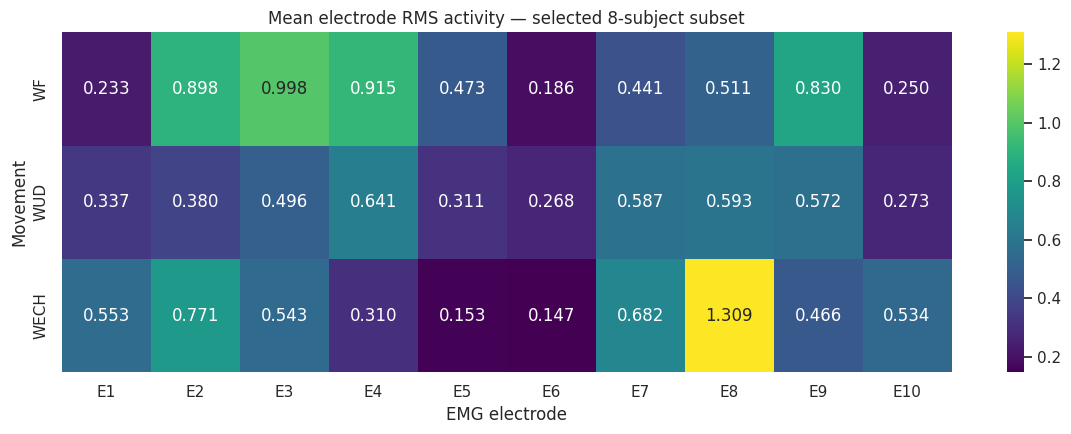

Electrode,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10
Movement,,,,,,,,,,
WF,0.2329,0.8981,0.9978,0.9155,0.4727,0.1855,0.4410,0.5110,0.8302,0.2496
WUD,0.3369,0.3800,0.4963,0.6407,0.3109,0.2678,0.5873,0.5926,0.5715,0.2732
WECH,0.5528,0.7708,0.5434,0.3098,0.1528,0.1471,0.6820,1.3093,0.4658,0.5341


Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/figures/selected_movement_electrode_rms_heatmap.png
Saved: /kaggle/working/ninapro_db1_full_eda/eda_outputs/tables/selected_movement_electrode_rms.csv


In [39]:
electrode_activity_rows = []

for subject in SELECTED_SUBJECTS:
    file_path = next(
        path
        for path in selected_paths
        if parse_file_ids(
            path
        )["subject"]
        == subject
    )

    data = load_db1(
        file_path
    )

    emg = np.asarray(
        data["emg"]
    )

    labels = np.asarray(
        data["restimulus"],
        dtype=np.int16,
    )

    for movement_label, movement_name in (
        SELECTED_MOVEMENTS.items()
    ):
        mask = (
            labels
            == movement_label
        )

        if not np.any(
            mask
        ):
            continue

        rms_per_electrode = np.sqrt(
            np.mean(
                emg[
                    mask
                ] ** 2,
                axis=0,
            )
        )

        for electrode_index, value in enumerate(
            rms_per_electrode,
            start=1,
        ):
            electrode_activity_rows.append(
                {
                    "Subject": (
                        subject
                    ),
                    "Movement": (
                        movement_name
                    ),
                    "Movement_label": (
                        movement_label
                    ),
                    "Electrode": (
                        f"E{electrode_index}"
                    ),
                    "RMS": (
                        float(
                            value
                        )
                    ),
                }
            )

electrode_activity_df = (
    pd.DataFrame(
        electrode_activity_rows
    )
)

electrode_activity_summary = (
    electrode_activity_df
    .groupby(
        [
            "Movement",
            "Electrode",
        ],
        as_index=False,
    )[
        "RMS"
    ]
    .mean()
)

electrode_order = [
    f"E{i}"
    for i in range(
        1,
        N_EMG + 1,
    )
]

movement_order = [
    "WF",
    "WUD",
    "WECH",
]

heatmap_data = (
    electrode_activity_summary
    .pivot(
        index="Movement",
        columns="Electrode",
        values="RMS",
    )
    .reindex(
        index=movement_order,
        columns=electrode_order,
    )
)

plt.figure(
    figsize=(
        12,
        4.5,
    )
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis",
)

plt.title(
    "Mean electrode RMS activity — selected 8-subject subset"
)

plt.xlabel(
    "EMG electrode"
)

plt.ylabel(
    "Movement"
)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / "selected_movement_electrode_rms_heatmap.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

display(
    heatmap_data.round(
        4
    )
)

table_path = (
    TABLE_DIR
    / "selected_movement_electrode_rms.csv"
)

electrode_activity_summary.to_csv(
    table_path,
    index=False,
)

print(
    "Saved:",
    figure_path,
)

print(
    "Saved:",
    table_path,
)

## O6. What these additional figures demonstrate

These plots support four important EDA observations:

### 1. Temporal synchronization
The EMG, glove, and movement-label signals share the same time axis and change together during movement periods.

### 2. Repetition variability
Even when the same subject performs the same movement repeatedly, the exact EMG amplitude and waveform are not identical across repetitions.

### 3. Target variability
The wrist-related glove trajectory also differs across repetitions, making the task a genuine continuous regression problem rather than simply reproducing one fixed waveform.

### 4. Electrode-specific activity
Different electrodes exhibit different RMS activity levels for WF, WUD, and WECH. This provides a useful motivation for representing electrodes as graph nodes and learning relationships between them.

## O7. Updated figure inventory

In [40]:
print(
    "All generated EDA figures:"
)

for path in sorted(
    FIGURE_DIR.glob(
        "*.png"
    )
):
    print(
        " -",
        path.name,
    )

All generated EDA figures:
 - active_emg_rms_by_exercise.png
 - all_movement_sample_counts.png
 - between_subject_variability.png
 - emg_channel_correlation.png
 - emg_glove_correlation.png
 - exercise_samples_duration.png
 - full_db1_emg_pca.png
 - repetition_overlay_EMG_S1_WECH.png
 - repetition_overlay_EMG_S1_WF.png
 - repetition_overlay_EMG_S1_WUD.png
 - representative_signal_distributions.png
 - rest_vs_movement_emg_rms.png
 - selected_emg_rms_by_movement.png
 - selected_emg_target_correlation.png
 - selected_movement_electrode_rms_heatmap.png
 - selected_subject_movement_heatmap.png
 - selected_subset_movement_counts.png
 - selected_target_glove_distributions.png
 - selected_temporal_examples.png
 - subject_exercise_duration_heatmap.png
 - synchronized_S1_E1.png
 - synchronized_S1_E2.png
 - synchronized_S1_E3.png
 - target_repetition_overlay_S1_WECH.png
 - target_repetition_overlay_S1_WF.png
 - target_repetition_overlay_S1_WUD.png
 - temporal_examples_all_exercises.png
